## Fit statistical time-series model
### 5-neuron gated recurrent unit



In [1]:
# Import required libraries

import pandas as pd
import os
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

In [2]:
# Reload all required data
output_dir = './output'
file_path = os.path.join(output_dir, 'yearly_mentions.csv')
yearly_mentions = pd.read_csv(file_path, lineterminator='\n', header=0, index_col=0)
yearly_mentions.index = pd.to_datetime(yearly_mentions.index)

file_path = os.path.join(output_dir, 'monthly_mentions.csv')
monthly_mentions = pd.read_csv(file_path, lineterminator='\n', header=0, index_col=0)
monthly_mentions.index = pd.to_datetime(monthly_mentions.index)

file_path = os.path.join(output_dir, 'weekly_mentions.csv')
weekly_mentions = pd.read_csv(file_path, lineterminator='\n', header=0, index_col=0)
weekly_mentions.index = pd.to_datetime(weekly_mentions.index)

In [3]:
file_path = os.path.join(output_dir, 'topics.csv')
topics = pd.read_csv(file_path, lineterminator='\n')

topic_names = topics['Name'].tolist()
topics

,Topic,Name,Words\r
0,0,Substance Use Disorder,"alcohol,opioid,substance,drinking,use,dependen..."
1,1,Gut-Brain Axis,"gut,microbiota,microbiome,probiotics,axis,inte..."
2,2,HIV/AIDS Management,"hiv,aids,antiretroviral,living,art,plwh,plhiv,..."
3,3,Suicidal behavior,"suicide,suicidal,ideation,attempts,nssi,attemp..."
4,4,Autism Spectrum Disorder,"autism,asd,autistic,spectrum,children,sensory,..."
...,...,...,...
968,968,Iron homeostasis and neurodegeneration,"iron,ferroptosis,lcn2,overload,labile,tbi,nrf2..."
969,969,Spinal pain management,"epidural,radicular,herniation,steroid,osteocho..."
970,970,Genetic Variants,"cnvs,variants,deletion,schizophrenia,deletions..."
971,971,Child Exposure to Domestic Violence,"domestic,violence,dv,children,exposed,actualiz..."


In [4]:
print(monthly_mentions.shape)

# Remove final month
monthly_mentions.drop(index='2025-03-31',inplace=True)
print(monthly_mentions.shape)

monthly_mentions.head()


(125, 973)
(124, 973)


,Topic0,Topic1,Topic2,Topic3,Topic4,Topic5,Topic6,Topic7,Topic8,Topic9,...,Topic963,Topic964,Topic965,Topic966,Topic967,Topic968,Topic969,Topic970,Topic971,Topic972
PubDate,,,,,,,,,,,,,,,,,,,,,
2015-01-31,23,5,30,23,22,18,33,15,35,21,...,2,8,10,3,9,2,1,2,7,12
2015-02-28,8,2,1,10,5,0,3,3,7,4,...,0,0,1,1,2,0,0,2,1,2
2015-03-31,15,2,7,23,3,5,8,5,10,4,...,1,3,3,0,2,0,0,0,3,2
2015-04-30,11,2,4,12,14,4,3,3,4,1,...,0,2,0,3,1,0,0,0,1,2
2015-05-31,8,1,8,14,2,4,4,3,6,3,...,0,2,2,2,1,0,1,0,1,1


In [5]:
# Reshape the monthly mentions dataset for the prediction model
monthly_data = monthly_mentions.melt(ignore_index=False).reset_index().set_index(['variable','PubDate']).sort_index()
print(monthly_data.shape)
monthly_data.head()


(120652, 1)


value
variable PubDate          
Topic0   2015-01-31     23
         2015-02-28      8
         2015-03-31     15
         2015-04-30     11
         2015-05-31      8

In [172]:
# Function to create sequences for time series
N_TIMESTEPS = 6
scaler = MinMaxScaler(feature_range=(0, 1))
model = None

# Prepare data for GRU (sliding window approach)
def create_dataset(data, look_back=N_TIMESTEPS):
    X, y = [], []
    unique_topics = data.index.get_level_values('variable').unique()
    for value in unique_topics:
        subset = data.xs(value, level='variable', drop_level=False)
        for i in range(len(subset)-look_back-1):
            a = subset.iloc[i:(i+look_back), 0]
            X.append(a)
            y.append(subset.iloc[i + look_back, 0])
    return np.array(X), np.array(y)


# Functions to train model and make predictions
def train_model(train_data):
    # use shared variables
    global scaler
    global model
    
    # Normalize the data
    train_data_scaled = pd.DataFrame(scaler.fit_transform(train_data),index=train_data.index,columns = train_data.columns)

    #train_data = scaler.fit_transform(train_data)
    #print(train_data.shape)
    X, y = create_dataset(train_data_scaled)
    
    # Reshape input to be [samples, time steps, features]
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))
    
    # Build GRU model
    model = Sequential()
    model.add(tf.keras.Input(shape=(N_TIMESTEPS,1))) # Input layer with input number of time steps
    model.add(GRU(10, return_sequences=True))
    model.add(GRU(10))
    model.add(Dense(1)) # Output layer with number of time steps to predict
    
    # Compile model
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    # Train the model
    model.fit(X, y, epochs=10, batch_size=32, verbose=1)

    # Make predictions
    predictions = model.predict(X)

    # Inverse transform the predictions
    predictions = scaler.inverse_transform(predictions)
    #y_actual = scaler.inverse_transform([y])
    y_actual = scaler.inverse_transform(y.reshape(-1,1))

    # Calculate MAE (Mean Absolute Error)
    #mae = mean_absolute_error(y_test_actual, y_pred) / np.mean(np.abs(y_test_actual - np.mean(y_test_actual)))
    mae = mean_absolute_error(predictions,y_actual)
    print(f'MAE for training run: {mae}')
    return(mae)

In [ ]:
# Train model on all data 
train_model(monthly_data)

In [174]:
def make_prediction(test_data): 
    # Use shared variables
    global scaler
    global model
    
    # Normalise data
    #test_data = scaler.transform(test_data)
    test_data_scaled = pd.DataFrame(scaler.fit_transform(test_data),index=test_data.index,columns = test_data.columns)
    
    X_test, y_test = create_dataset(test_data_scaled)

    # Reshape input to be [samples, time steps, features]
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
        
    # Make a prediction 
    y_pred_scaled = model.predict(X_test)
    
    y_pred = scaler.inverse_transform(y_pred_scaled)    
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)) 

    return y_test_actual, y_pred

### Systematically determine topic trendiness 

In [ ]:
import math
import random

trendy_topics = []
N_MONTHS = 6
N_OF_MONTHS = 4

for topicn in range(len(topic_names)):
    # Select the rows for the *other* topics, not the topics that we want to predict now
    mask = ~monthly_data.index.get_level_values('variable').isin(['Topic'+str(topicn)])
    train_data_subset = monthly_data.loc[mask]
    mae = train_model(train_data_subset)

    monthly_test_data = monthly_data.xs('Topic'+str(topicn), level='variable', drop_level=False)
    actual, predicted = make_prediction(monthly_test_data)
    
    last_six_actual = actual[-N_MONTHS:]
    last_six_pred = predicted[-N_MONTHS:]
    count_pred_actual = sum([a>p for (a,p) in zip(last_six_actual,last_six_pred)])
    trendy = count_pred_actual > N_OF_MONTHS  # Four of the last six months exceeded the prediction
    trendy = trendy[0]
    trendy_rank = [ 0 if a < p else float((a-p)*(math.e ** (1/(N_MONTHS-i)))) for i,(a,p) in enumerate(zip(last_six_actual,last_six_pred))]
    trendy_rank_s = sum(trendy_rank)/(np.mean(topicdata) if np.mean(topicdata) > 1 else 1) # Divide by the mean of the topic's counts to normalise

    pred_dict = {'Pred_M'+str(ts):p[0] for (ts,p) in enumerate(predicted)} 
    
    # Save the prediction for plotting later
    topic_dict = {"Topic":topicn,"TopicName":topic_names[topicn],"Trendy":trendy,"RankSum":trendy_rank_s,"ModelMAE":mae} | pred_dict
    print(topic_dict)
    trendy_topics.append(topic_dict)
    if (topicn % 100 == 0):  # Save interim results
        df_trendy_preds = pd.DataFrame(trendy_topics)
        df_trendy_preds.to_csv("output/trendy_predictions.csv")

# Save final results
df_trendy_preds = pd.DataFrame(trendy_topics)
df_trendy_preds.to_csv("output/trendy_predictions.csv")
df_trendy_preds

In [7]:
import os
import pandas as pd

file_path = os.path.join('./output', 'trendy_predictions.csv')
df_trendy_preds = pd.read_csv(file_path, lineterminator='\n',index_col=0)

df_trendy_preds.head()


,Topic,TopicName,Trendy,RankSum,NewRankSum,ModelMAE,Pred_M0,Pred_M1,Pred_M2,Pred_M3,...,Pred_M107,Pred_M108,Pred_M109,Pred_M110,Pred_M111,Pred_M112,Pred_M113,Pred_M114,Pred_M115,Pred_M116
0,0,Substance Use Disorder,False,1.785512,1.276823,1.561046,8.715691,7.947561,8.159626,7.277729,...,14.109028,14.624162,13.462335,12.783575,12.245189,12.146386,11.163840,11.011703,11.156823,11.584832
1,1,Gut-Brain Axis,True,7.234866,6.229362,1.562623,2.002838,1.525779,1.361958,1.216151,...,17.265482,17.293707,16.222216,16.083650,15.338812,15.063478,15.203836,13.680077,13.962671,15.476844
2,2,HIV/AIDS Management,False,2.721747,2.230937,1.573465,5.768834,5.675216,5.787230,6.566366,...,12.652901,11.133968,9.778062,9.905677,10.053457,10.643117,9.737912,9.357060,10.151107,11.546524
3,3,Suicidal behavior,False,2.602206,2.040916,1.567356,10.605254,10.989678,9.807891,10.024359,...,17.822561,18.593584,17.341358,17.579605,17.331491,17.219450,15.406489,16.048397,16.832943,17.651134
4,4,Autism Spectrum Disorder,True,5.052738,3.600085,1.460914,4.009576,3.878480,3.890851,4.380619,...,8.755921,9.329988,10.026917,10.459433,8.212244,8.231470,9.228279,8.881990,9.284045,8.435618


In [8]:
df_trendy_preds.head()

,Topic,TopicName,Trendy,RankSum,NewRankSum,ModelMAE,Pred_M0,Pred_M1,Pred_M2,Pred_M3,...,Pred_M107,Pred_M108,Pred_M109,Pred_M110,Pred_M111,Pred_M112,Pred_M113,Pred_M114,Pred_M115,Pred_M116
0,0,Substance Use Disorder,False,1.785512,1.276823,1.561046,8.715691,7.947561,8.159626,7.277729,...,14.109028,14.624162,13.462335,12.783575,12.245189,12.146386,11.163840,11.011703,11.156823,11.584832
1,1,Gut-Brain Axis,True,7.234866,6.229362,1.562623,2.002838,1.525779,1.361958,1.216151,...,17.265482,17.293707,16.222216,16.083650,15.338812,15.063478,15.203836,13.680077,13.962671,15.476844
2,2,HIV/AIDS Management,False,2.721747,2.230937,1.573465,5.768834,5.675216,5.787230,6.566366,...,12.652901,11.133968,9.778062,9.905677,10.053457,10.643117,9.737912,9.357060,10.151107,11.546524
3,3,Suicidal behavior,False,2.602206,2.040916,1.567356,10.605254,10.989678,9.807891,10.024359,...,17.822561,18.593584,17.341358,17.579605,17.331491,17.219450,15.406489,16.048397,16.832943,17.651134
4,4,Autism Spectrum Disorder,True,5.052738,3.600085,1.460914,4.009576,3.878480,3.890851,4.380619,...,8.755921,9.329988,10.026917,10.459433,8.212244,8.231470,9.228279,8.881990,9.284045,8.435618


Axes(0.125,0.11;0.775x0.77)
1.5239333429349575
0.05750869452314101


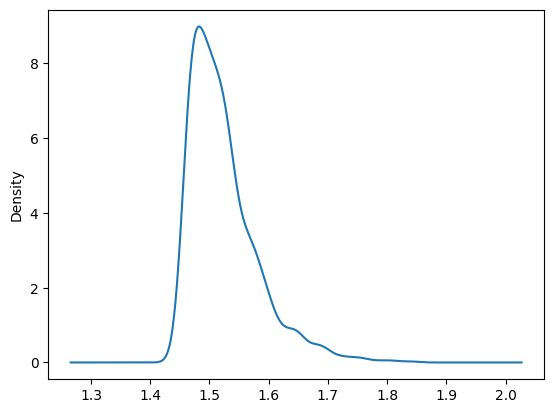

In [2]:
print(df_trendy_preds['ModelMAE'].plot.density())
print(df_trendy_preds['ModelMAE'].mean())
print(df_trendy_preds['ModelMAE'].std())

In [36]:
df_trendy_preds.to_csv("output/trendy_predictions_newrank.csv")

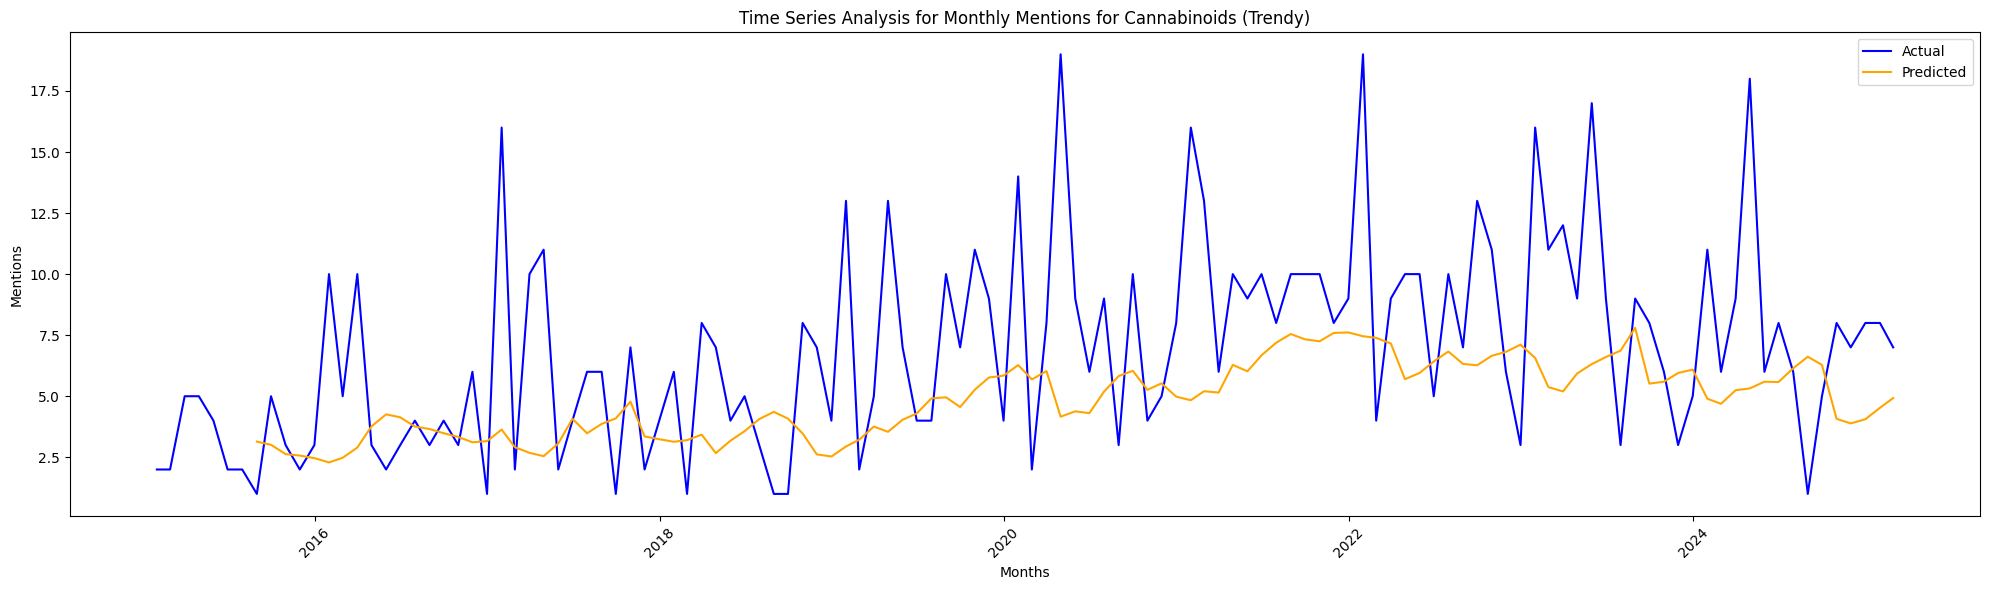

In [11]:
import matplotlib.pyplot as plt

N_TIMESTEPS=6

# Plot results for monthly mentions for a given topic
def plotTopic(topicn):
    topicdata = monthly_mentions.loc[:,'Topic'+str(topicn)][:-2]
    topicname = topic_names[topicn]
    predictdata = df_trendy_preds.filter(like='Pred_').iloc[topicn,][:-2]
    trendy = df_trendy_preds['Trendy'].iloc[topicn,]
    trendydesc = "Trendy" if trendy else "Not Trendy"
    plt.figure(figsize=(20, 6))
    #plt.plot(months[N_TIMESTEPS+1:], y_test_actual_monthly[:,], label='Actual', color='blue')
    plt.plot(topicdata,label="Actual",color='blue')
    plt.plot(topicdata.index[N_TIMESTEPS+1:], predictdata, label='Predicted', color='orange')
    plt.title(f'Time Series Analysis for Monthly Mentions for {topicname} ({trendydesc})')
    plt.xlabel('Months')
    plt.ylabel('Mentions')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

plotTopic(10)

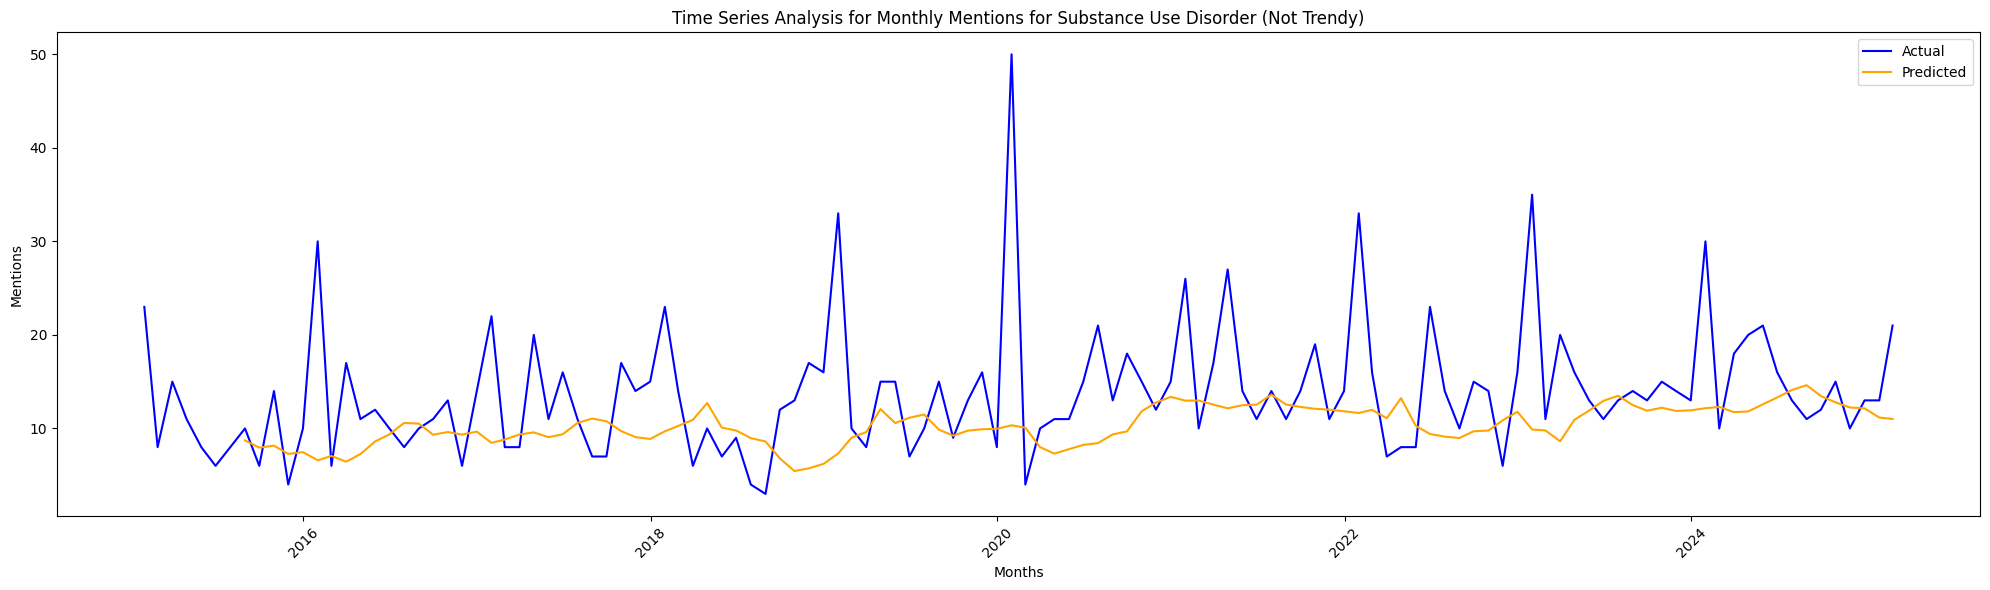

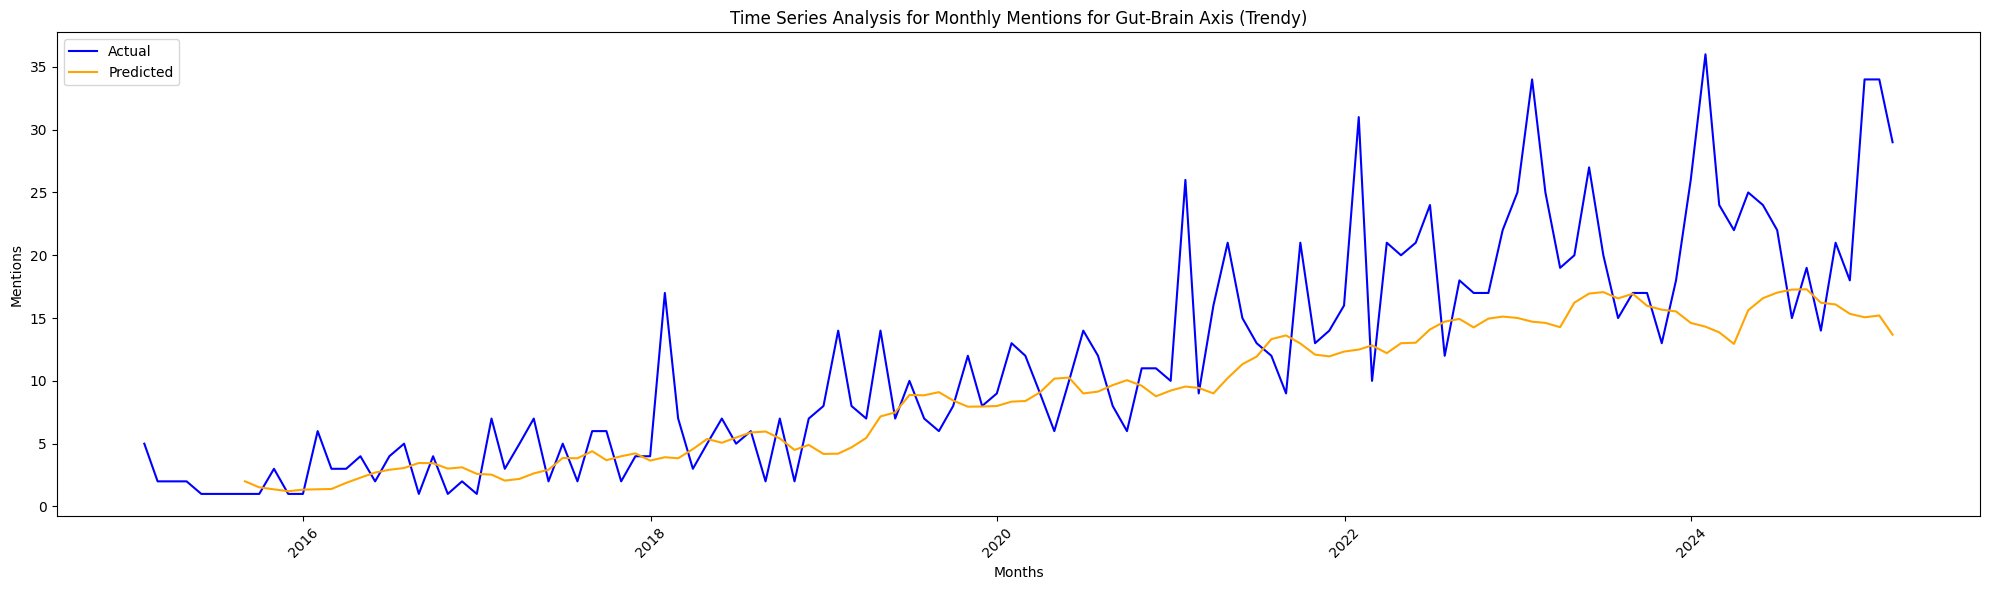

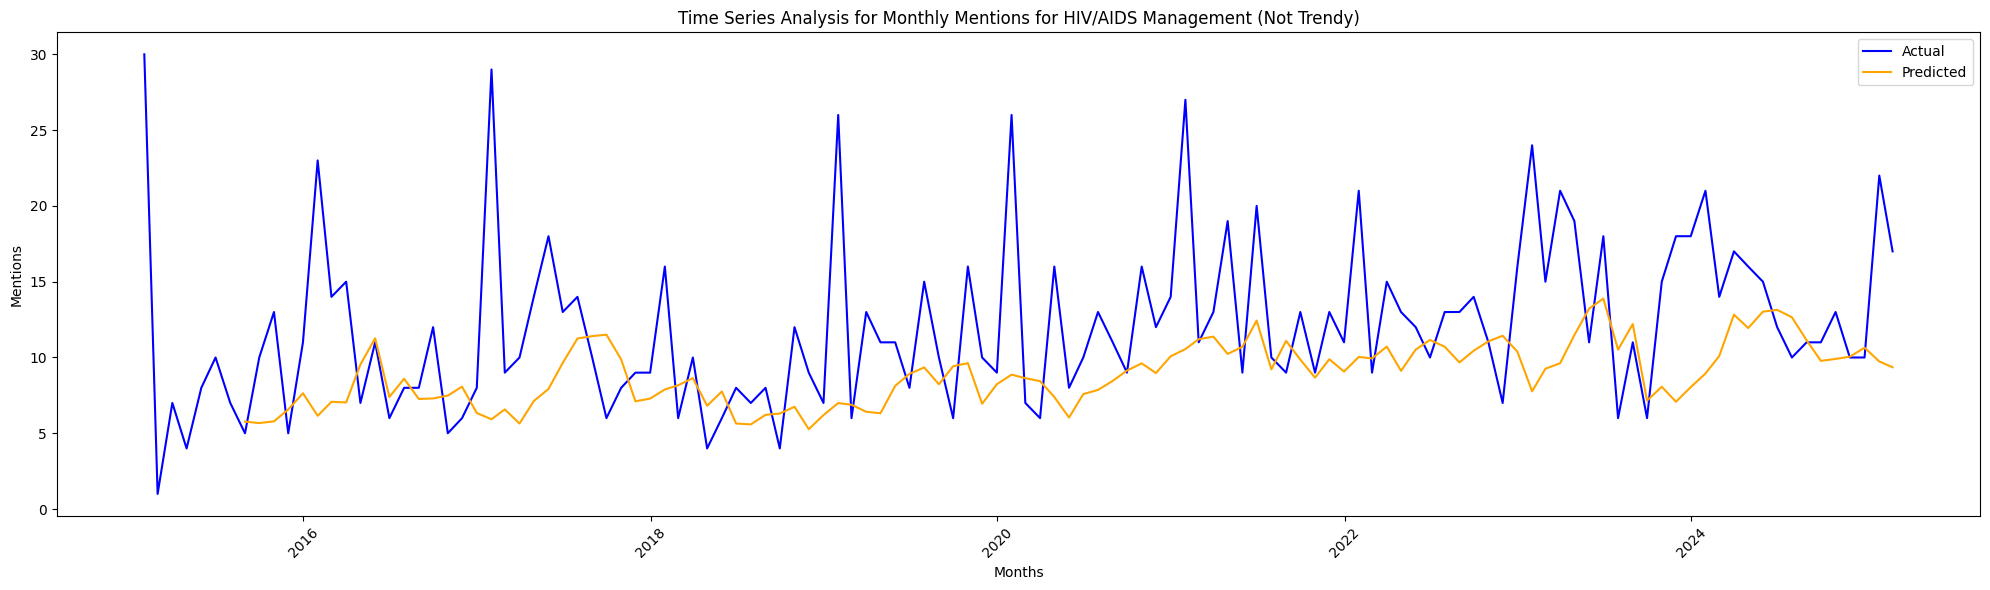

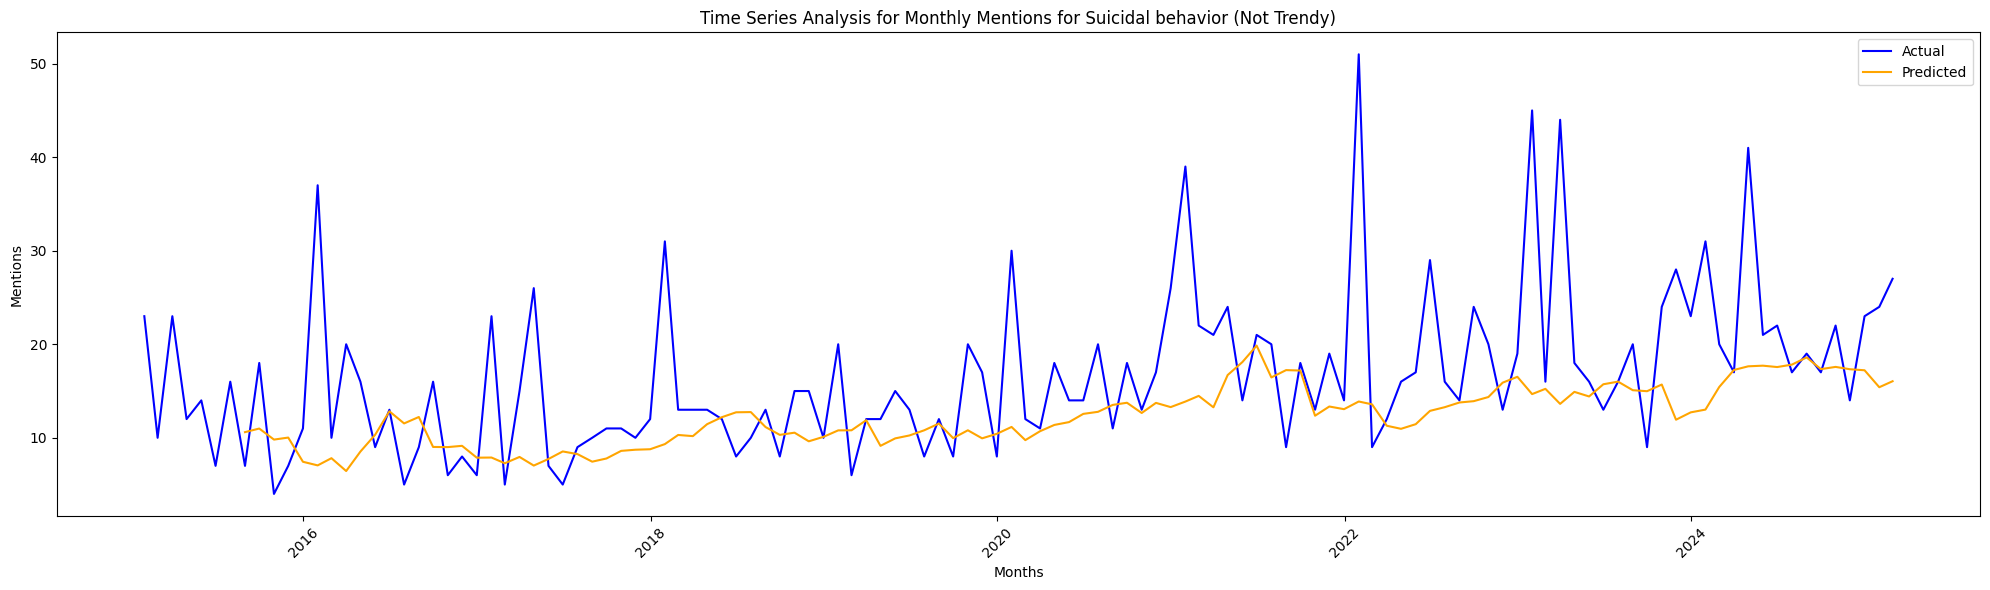

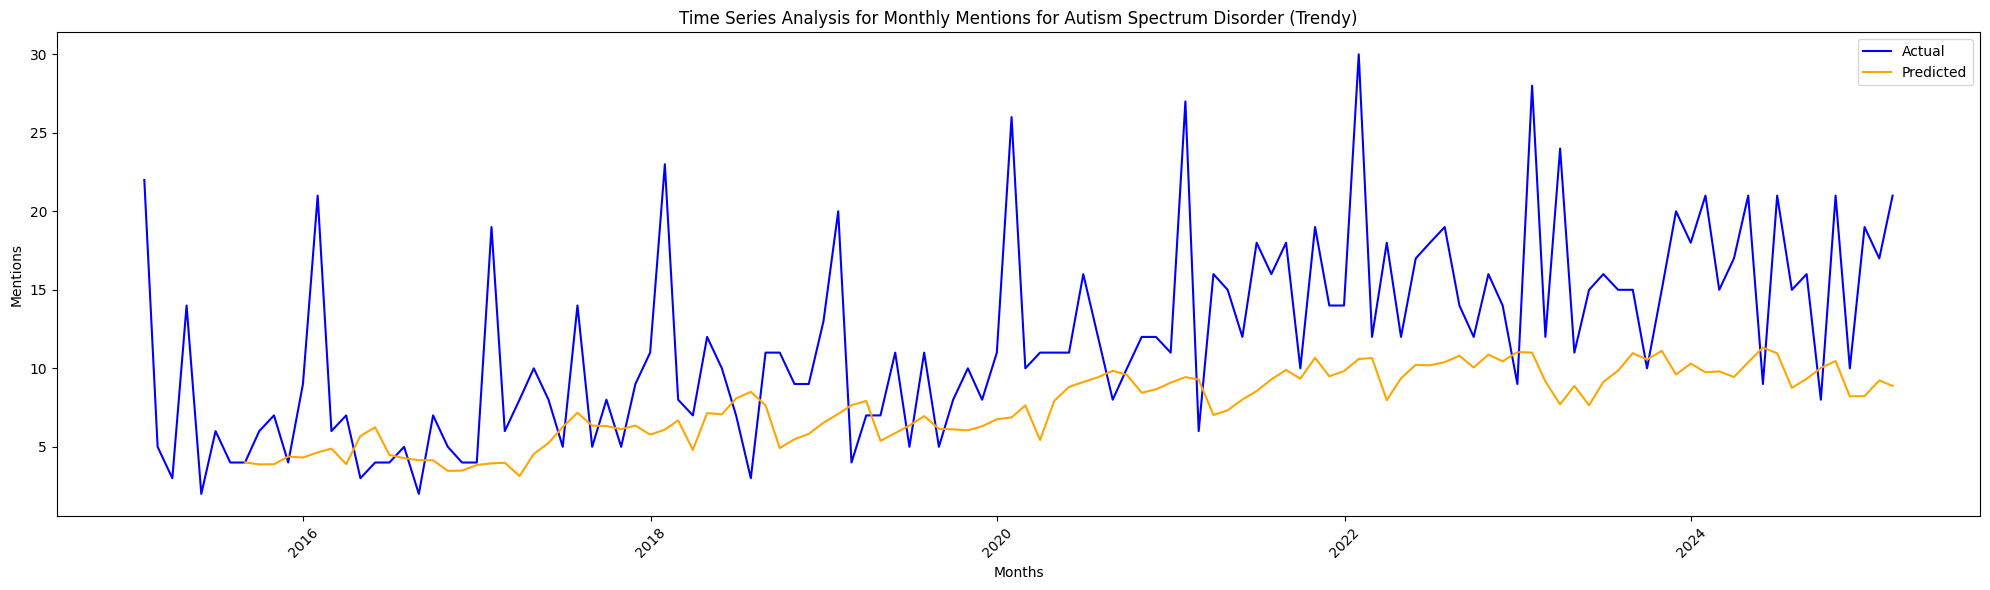

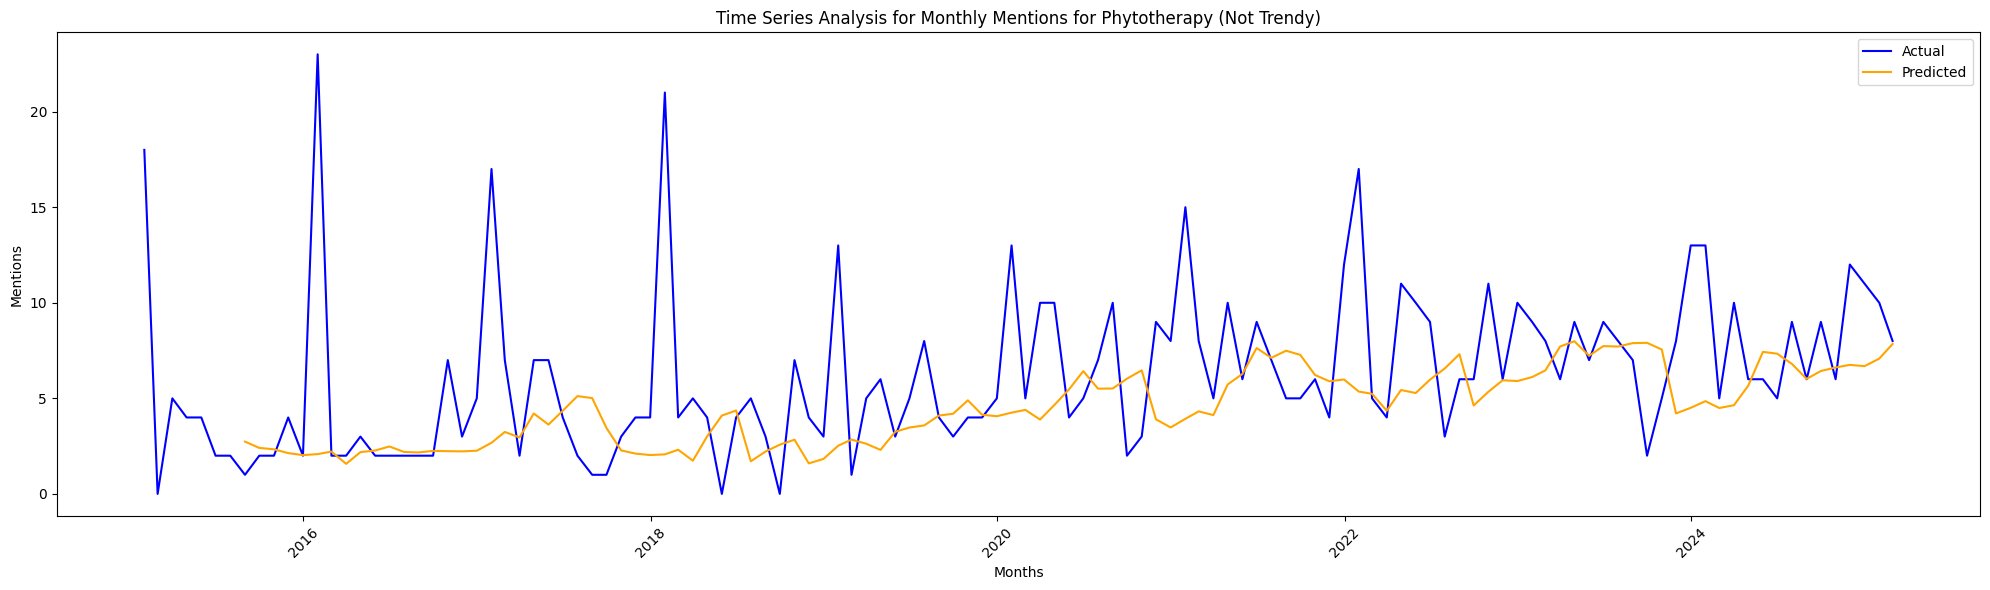

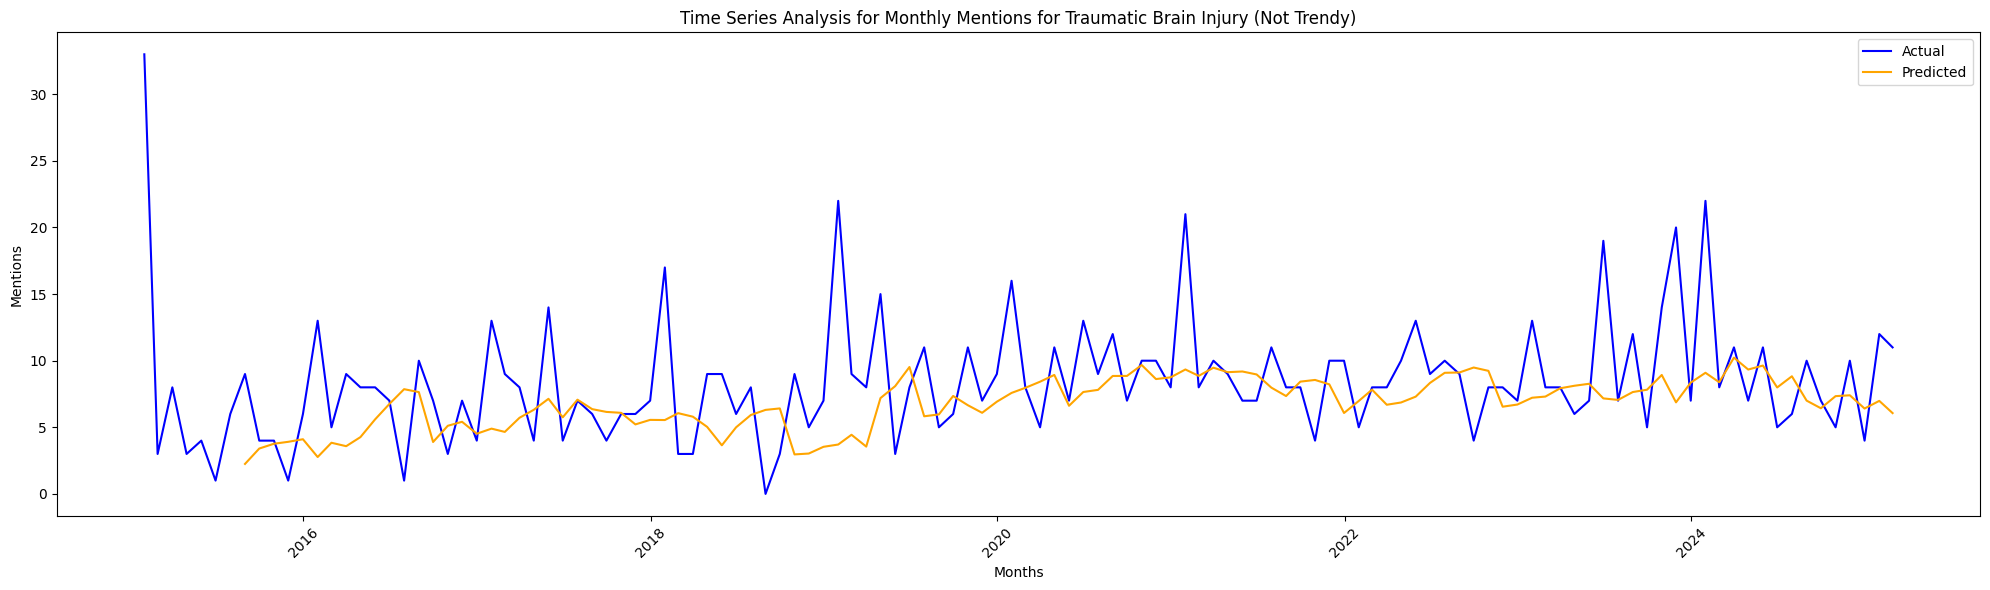

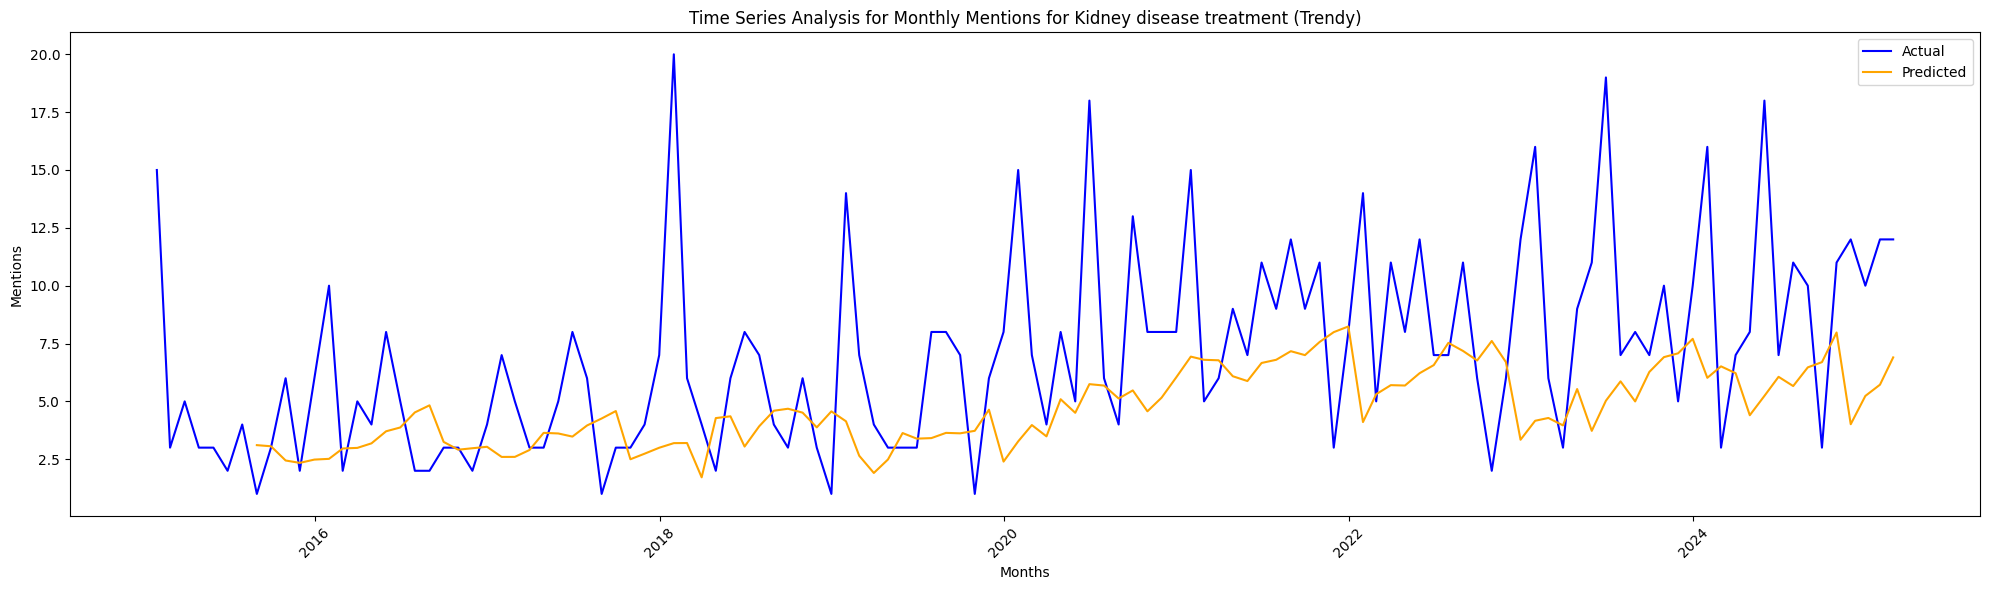

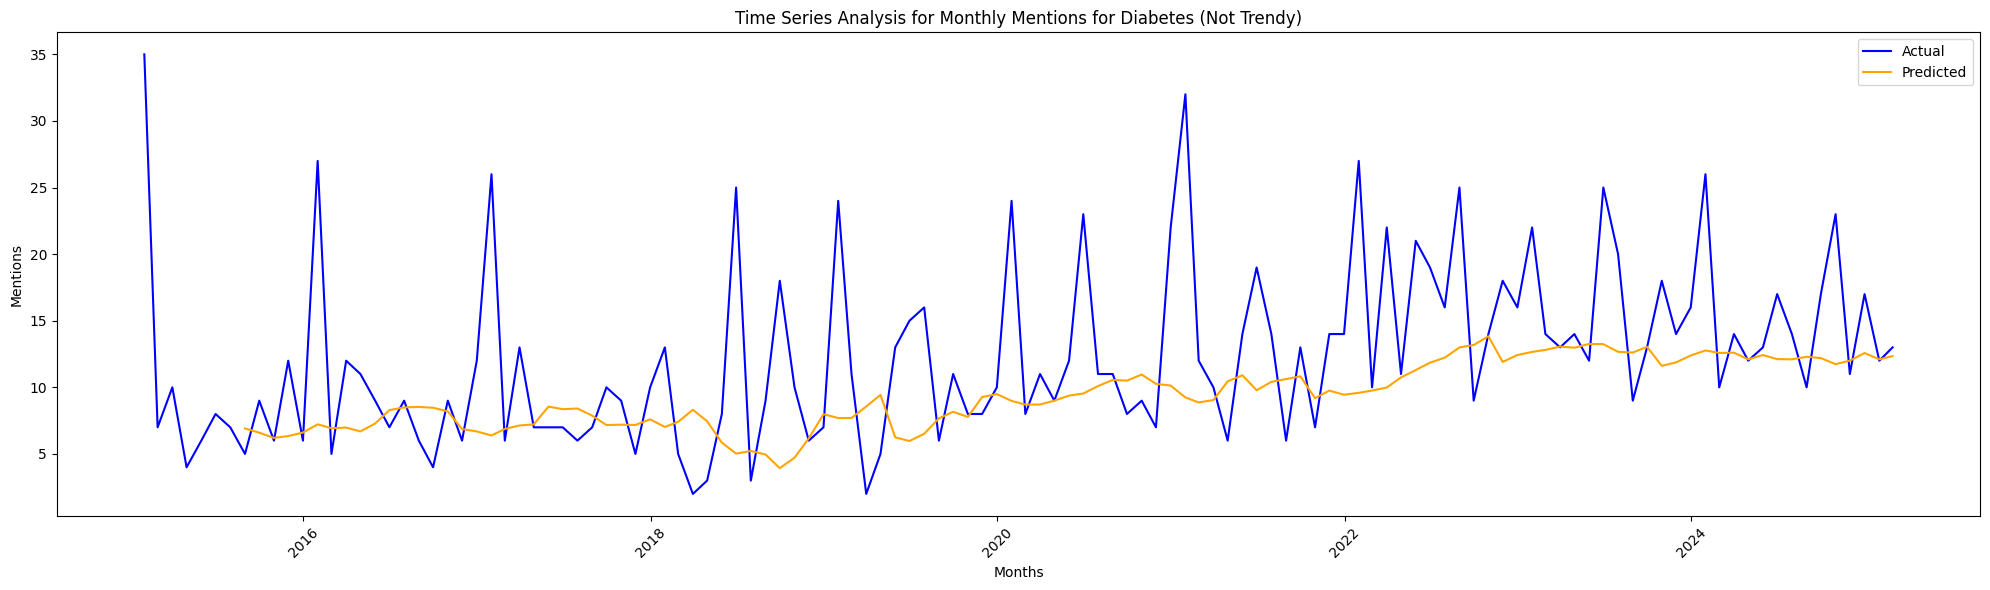

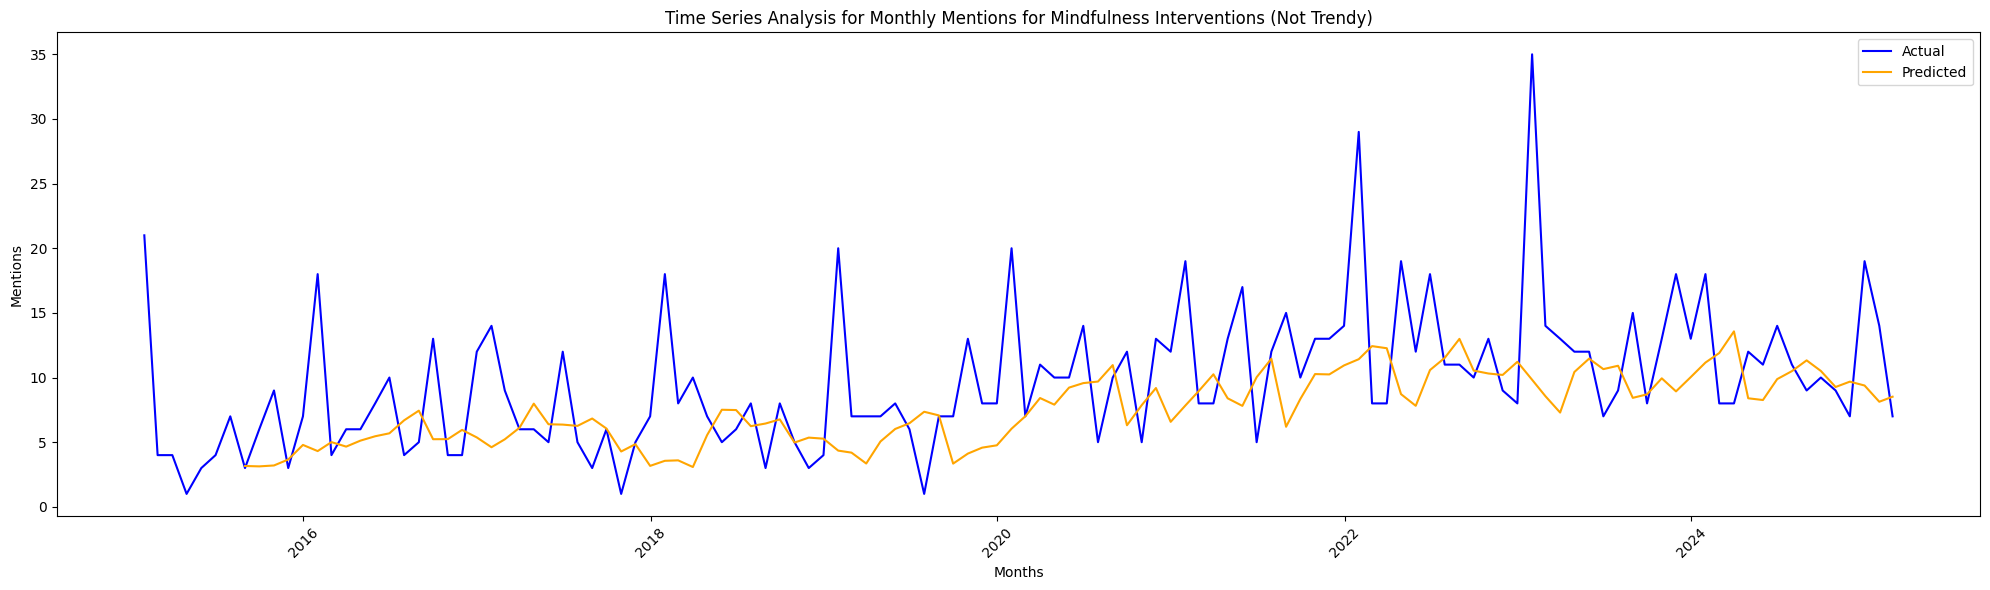

In [12]:
for i in range(10): 
    plotTopic(i)

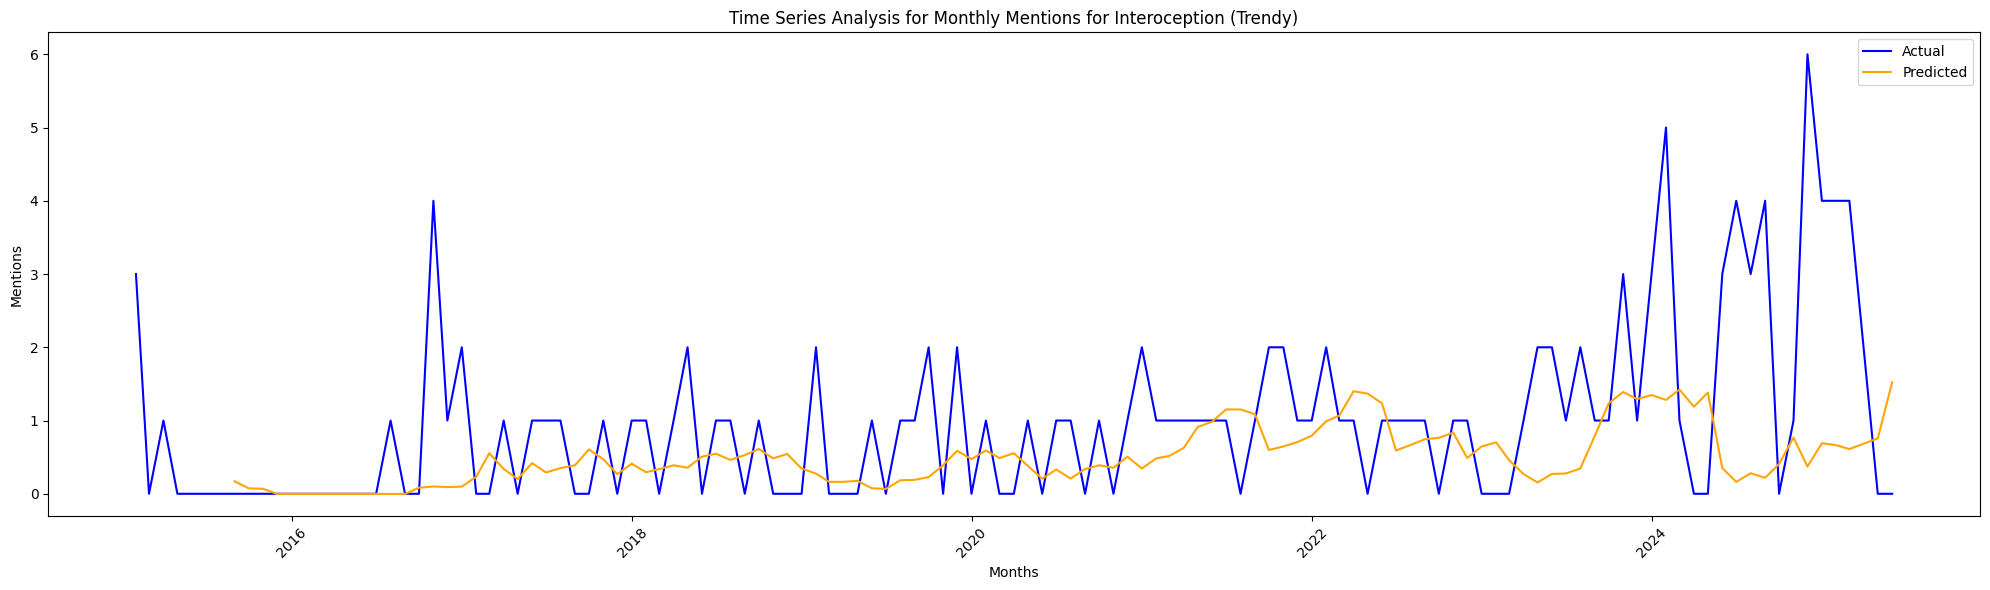

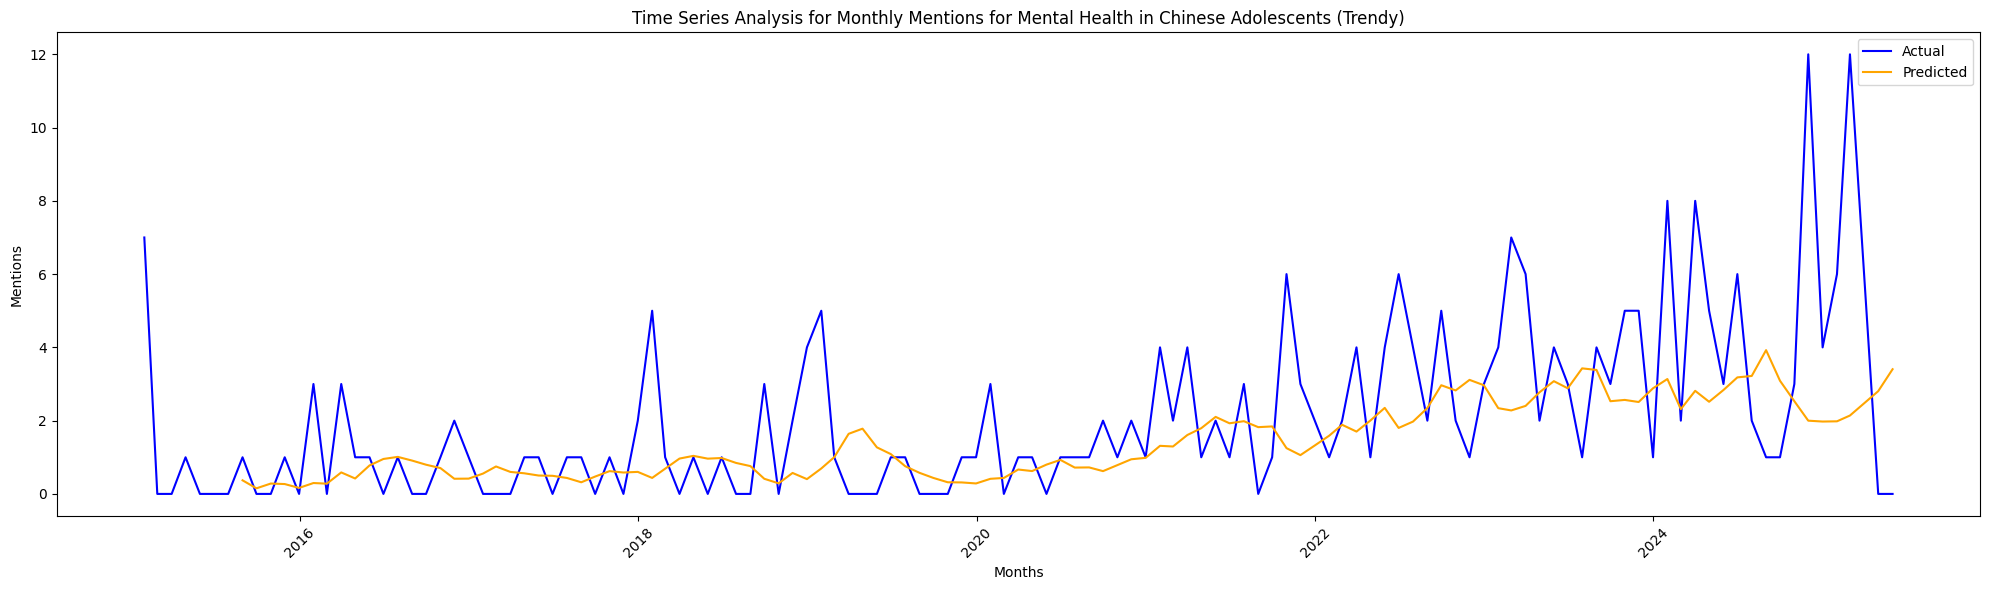

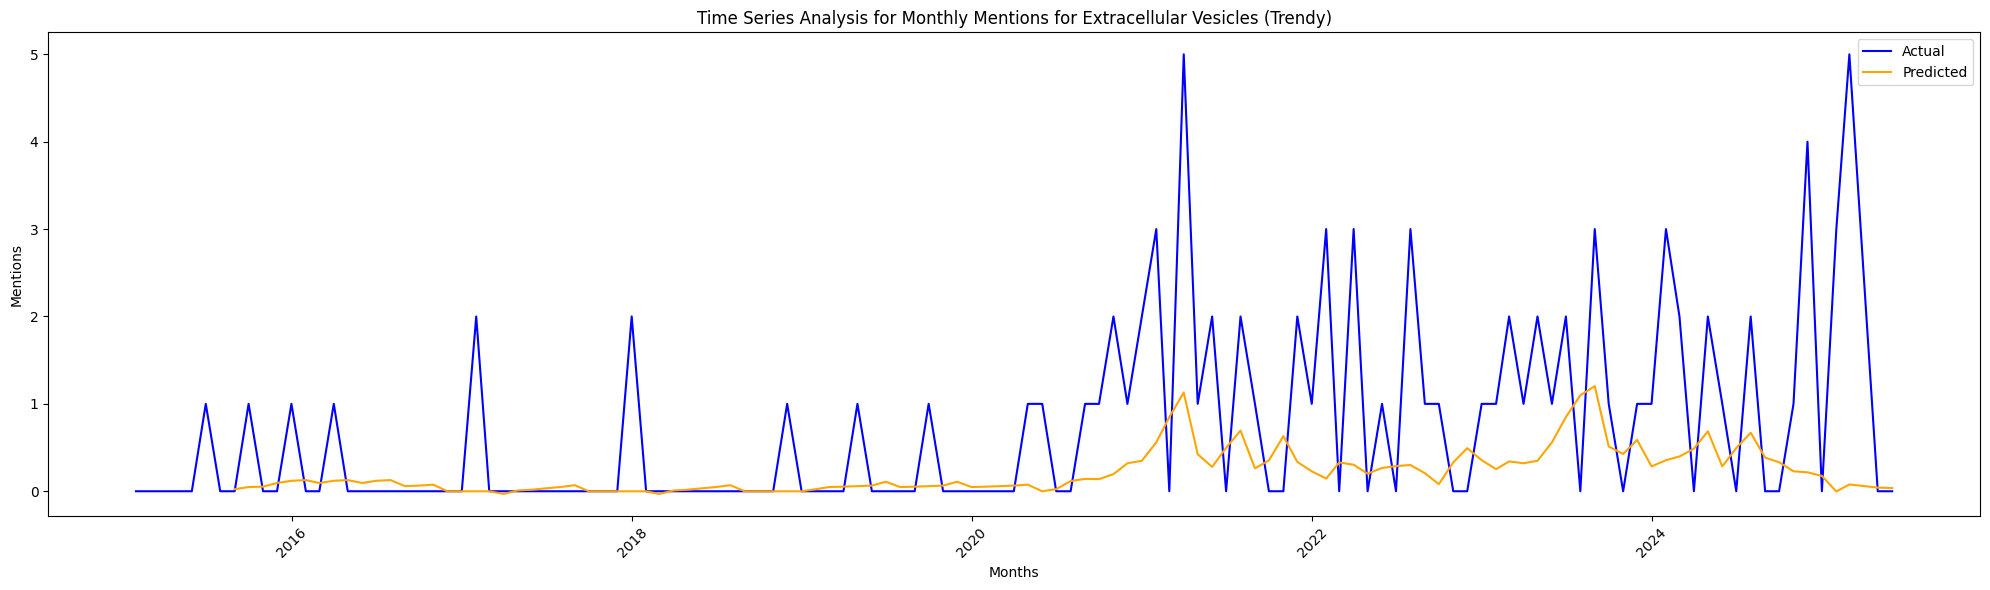

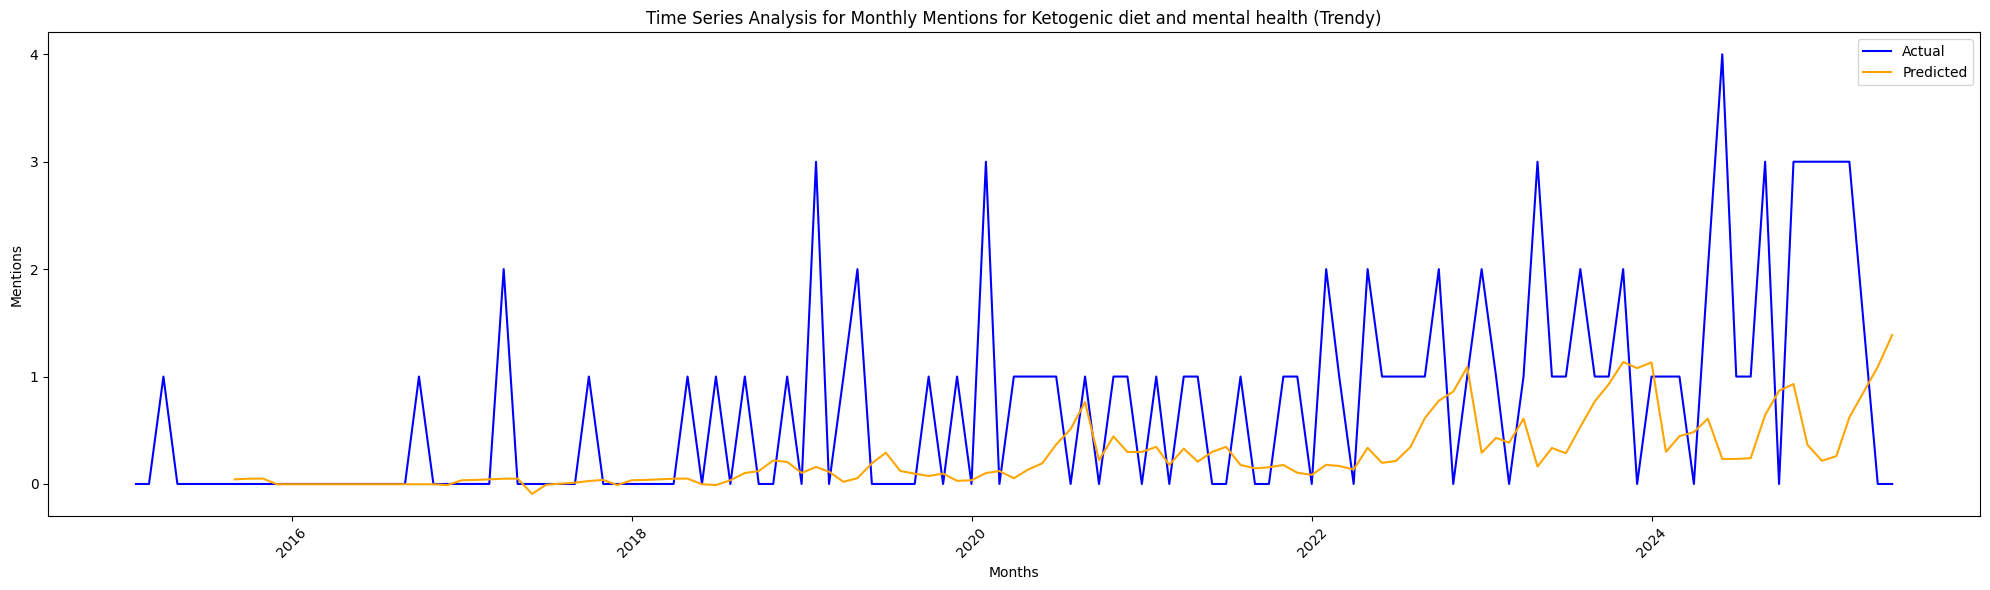

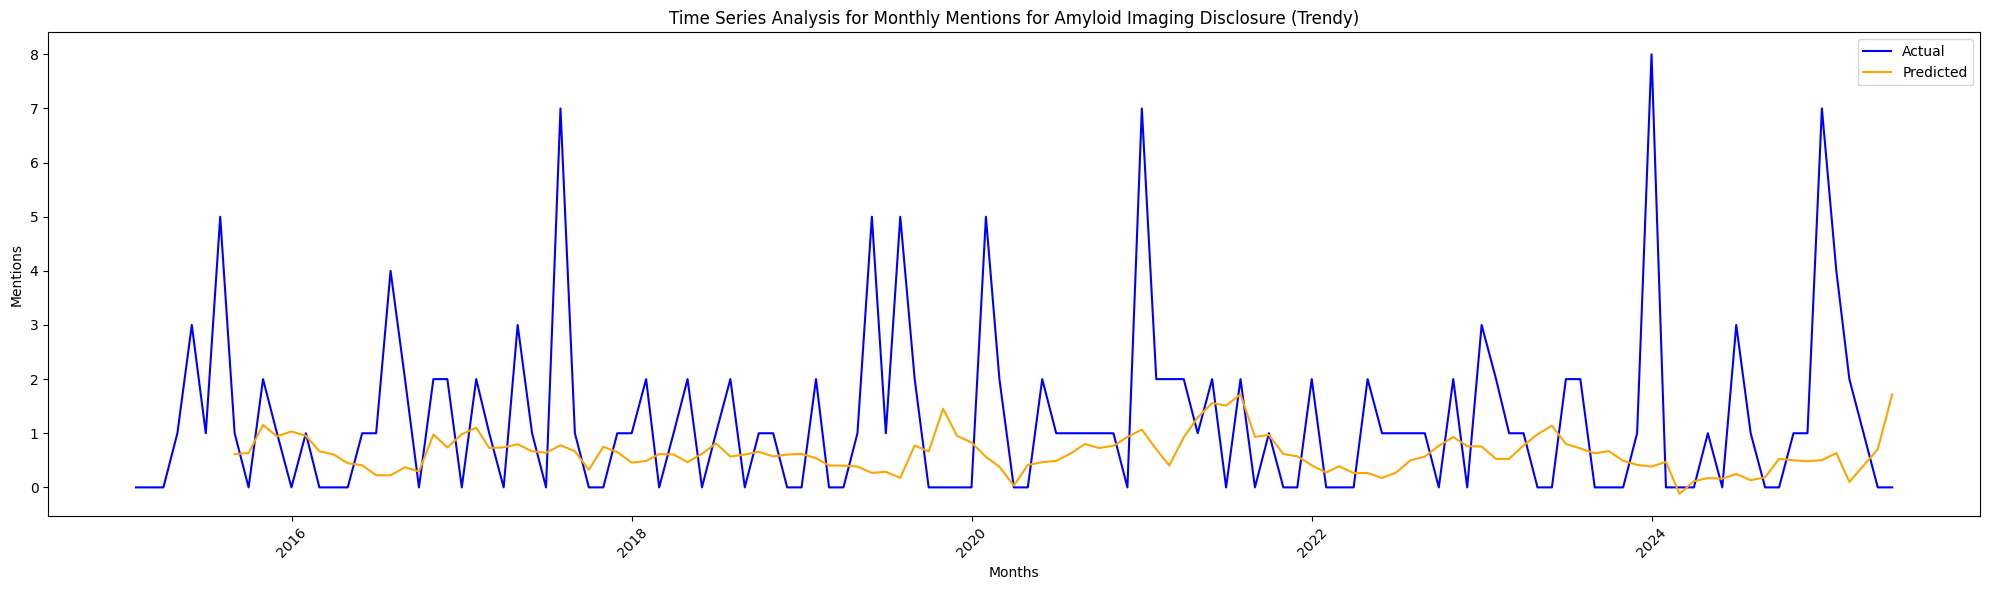

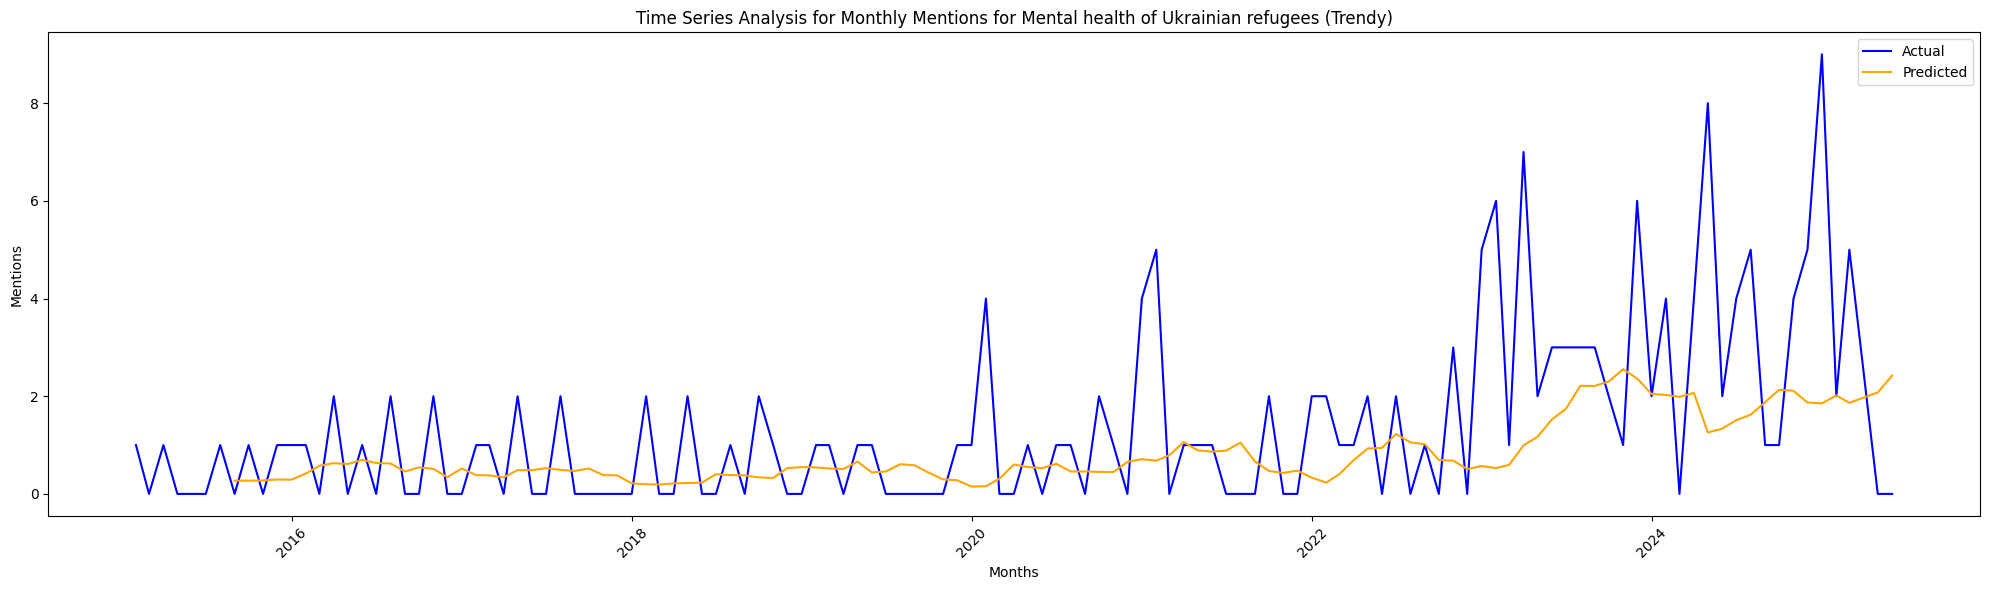

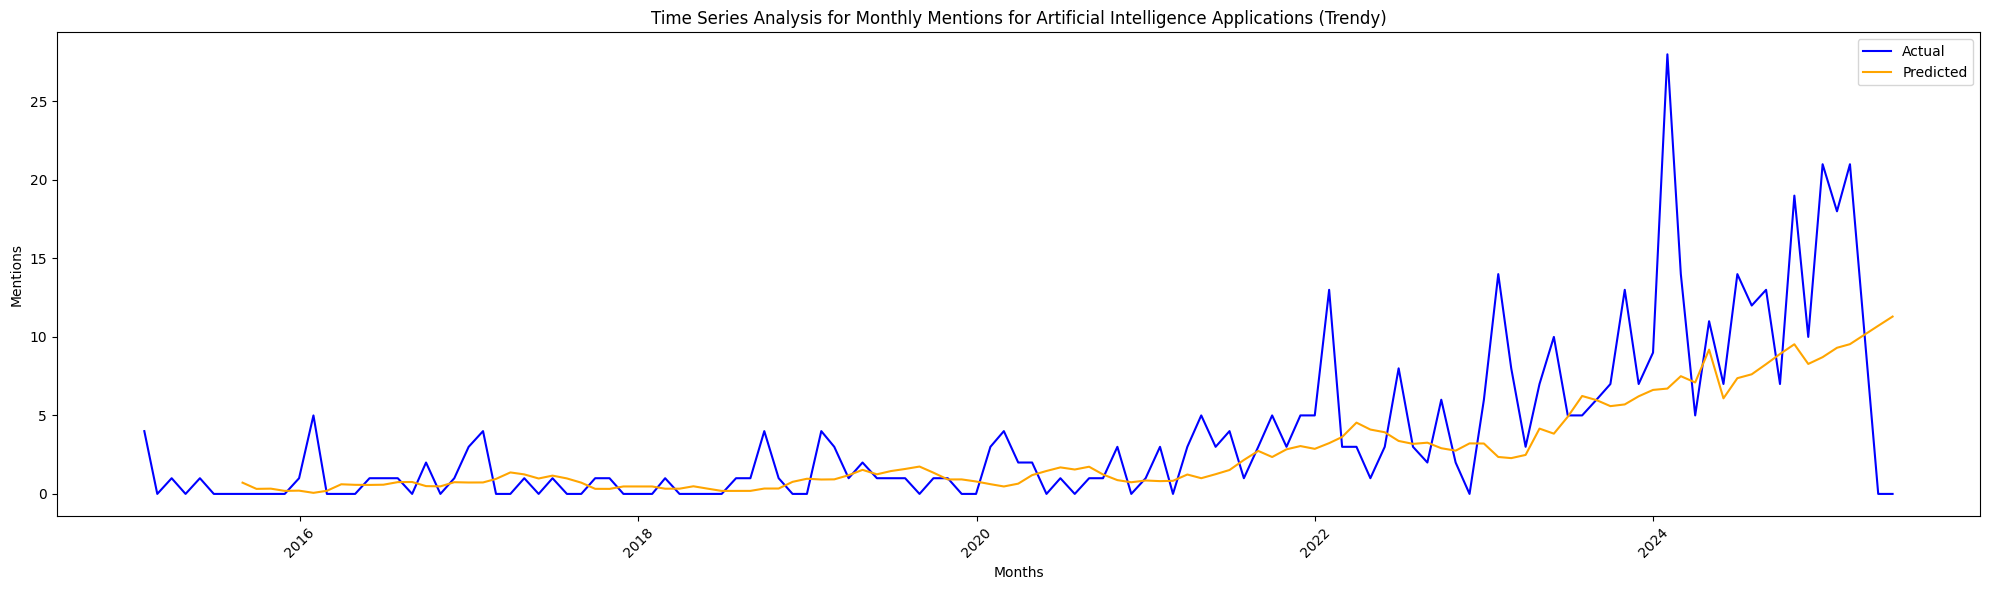

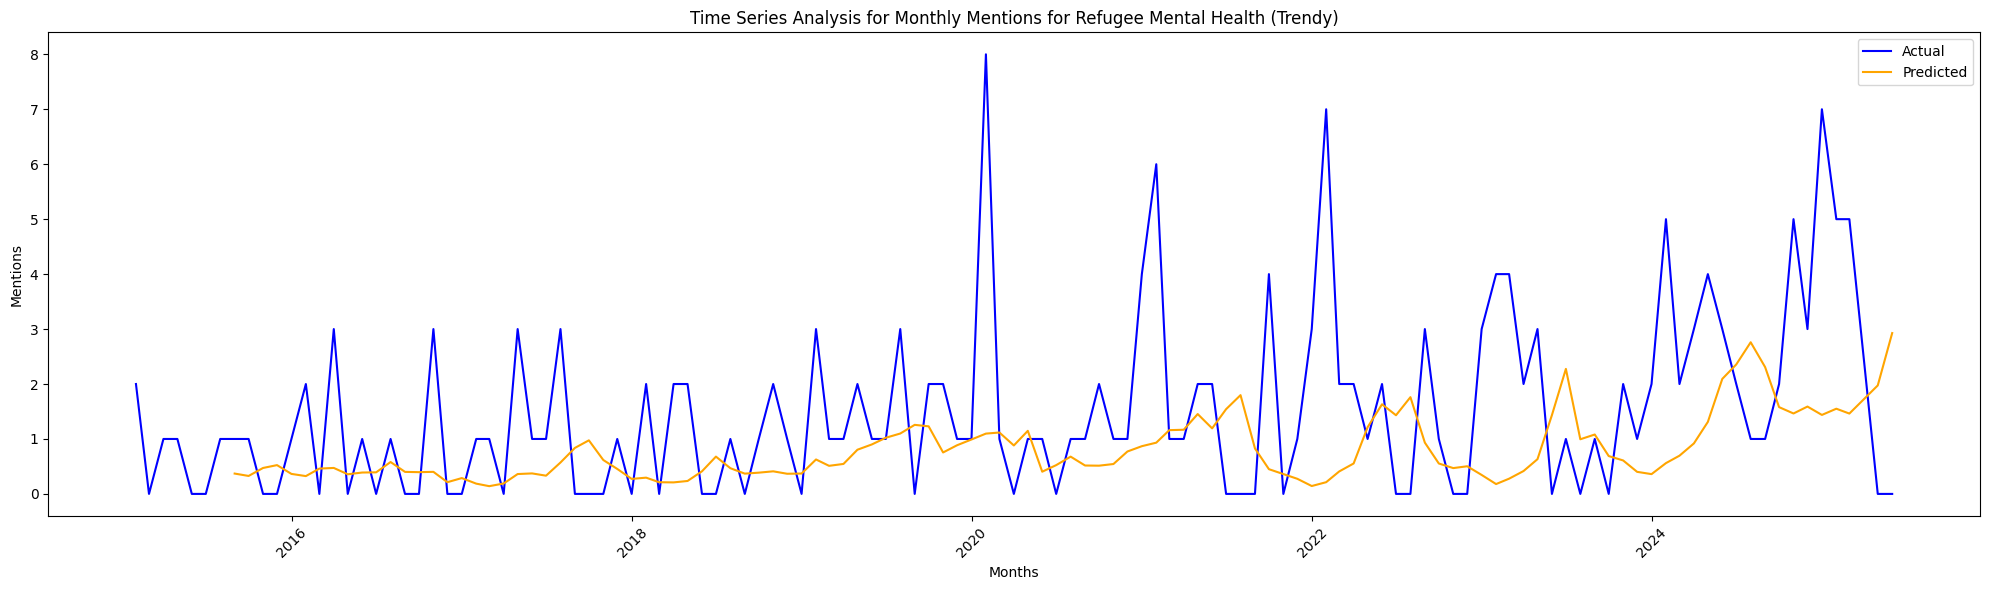

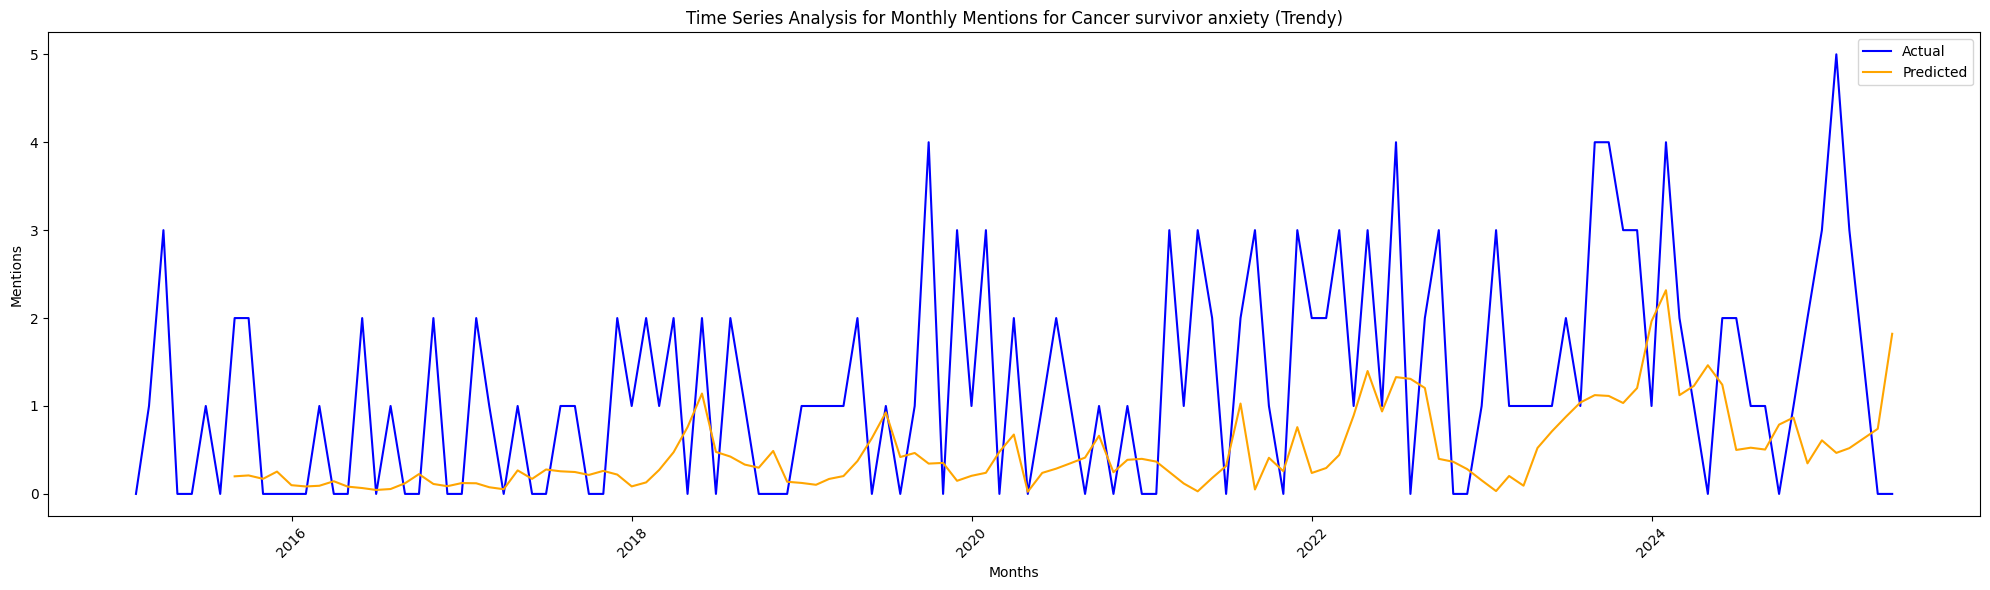

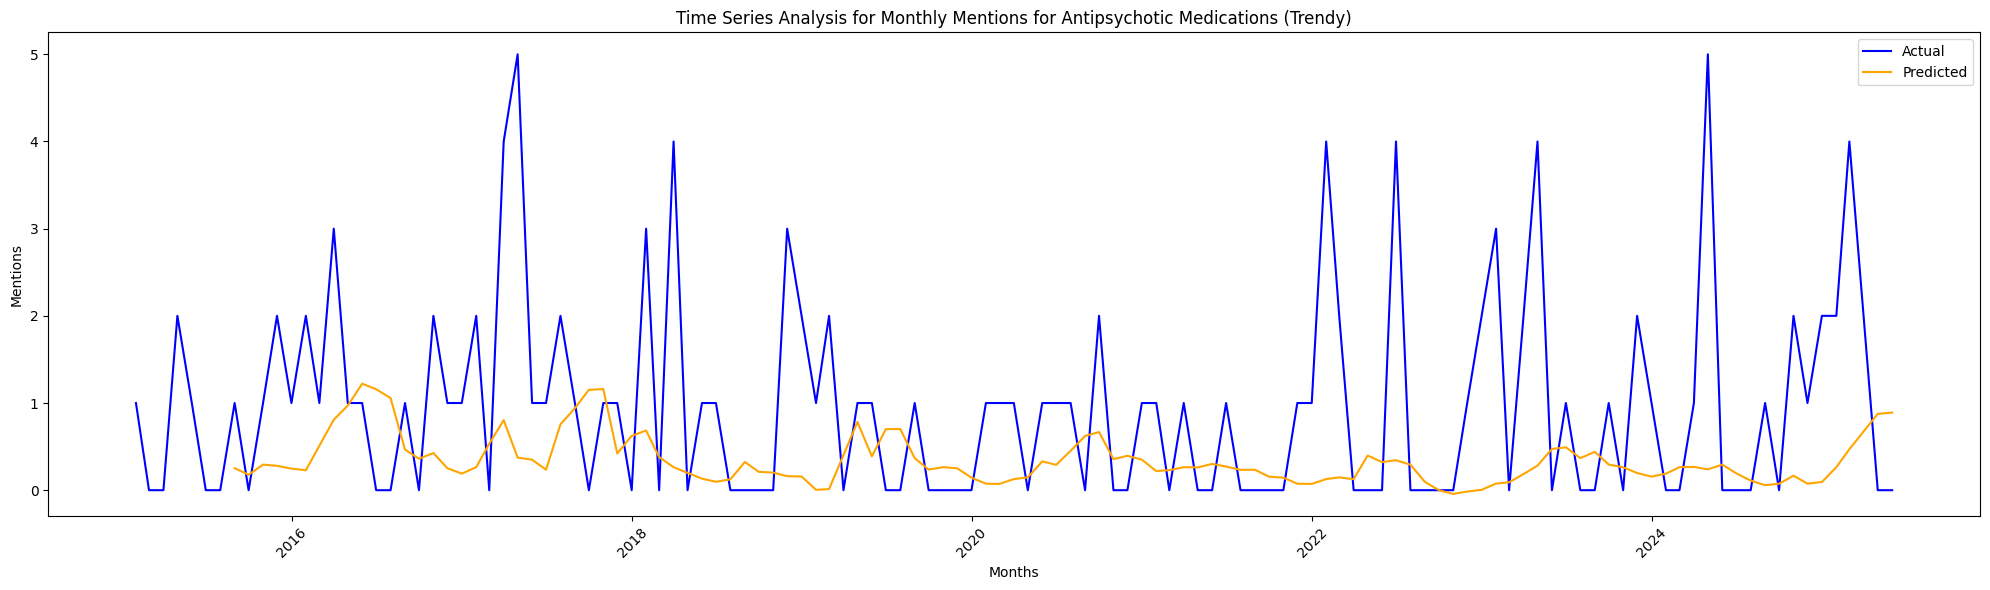

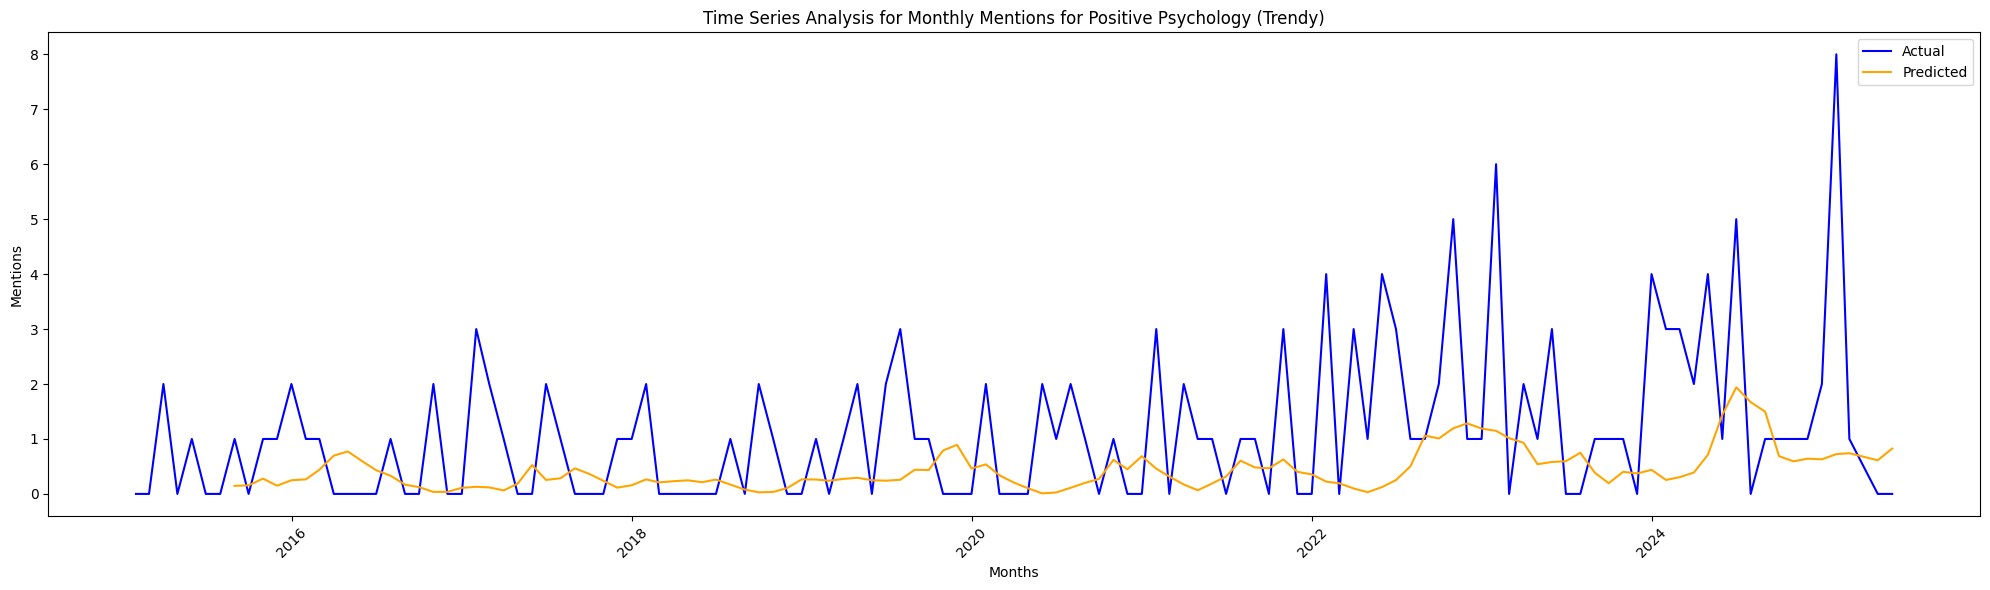

In [38]:
for i in [708, 173, 683, 488, 608, 874, 336, 409, 947, 652, 393]: # Now these are the 10 top-ranked topics with the new ranking... 
    plotTopic(i)

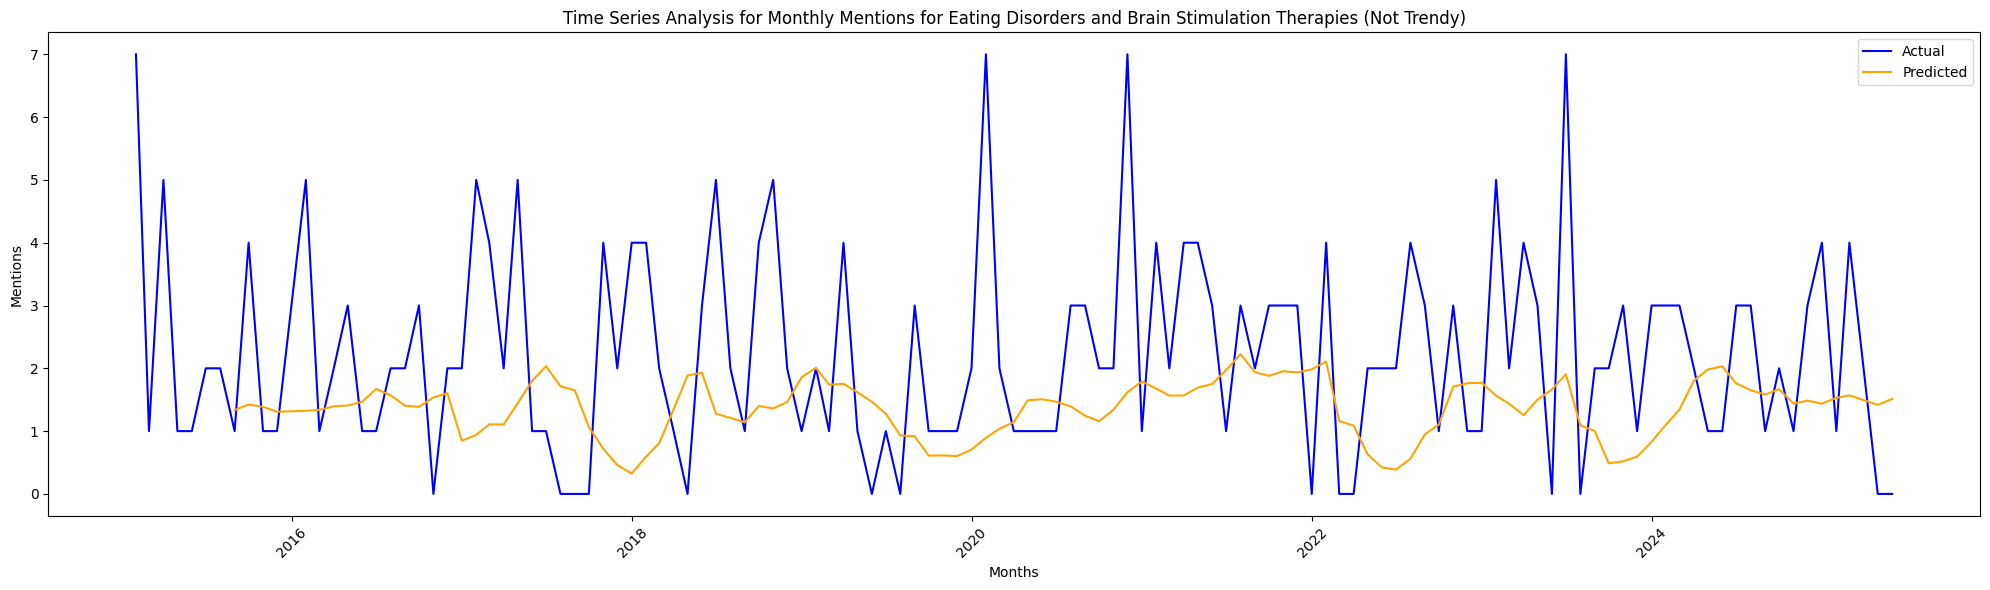

In [48]:
#for i in [37,38,39]:
#    plotTopic(i)

#plotTopic(3)

plotTopic(606)

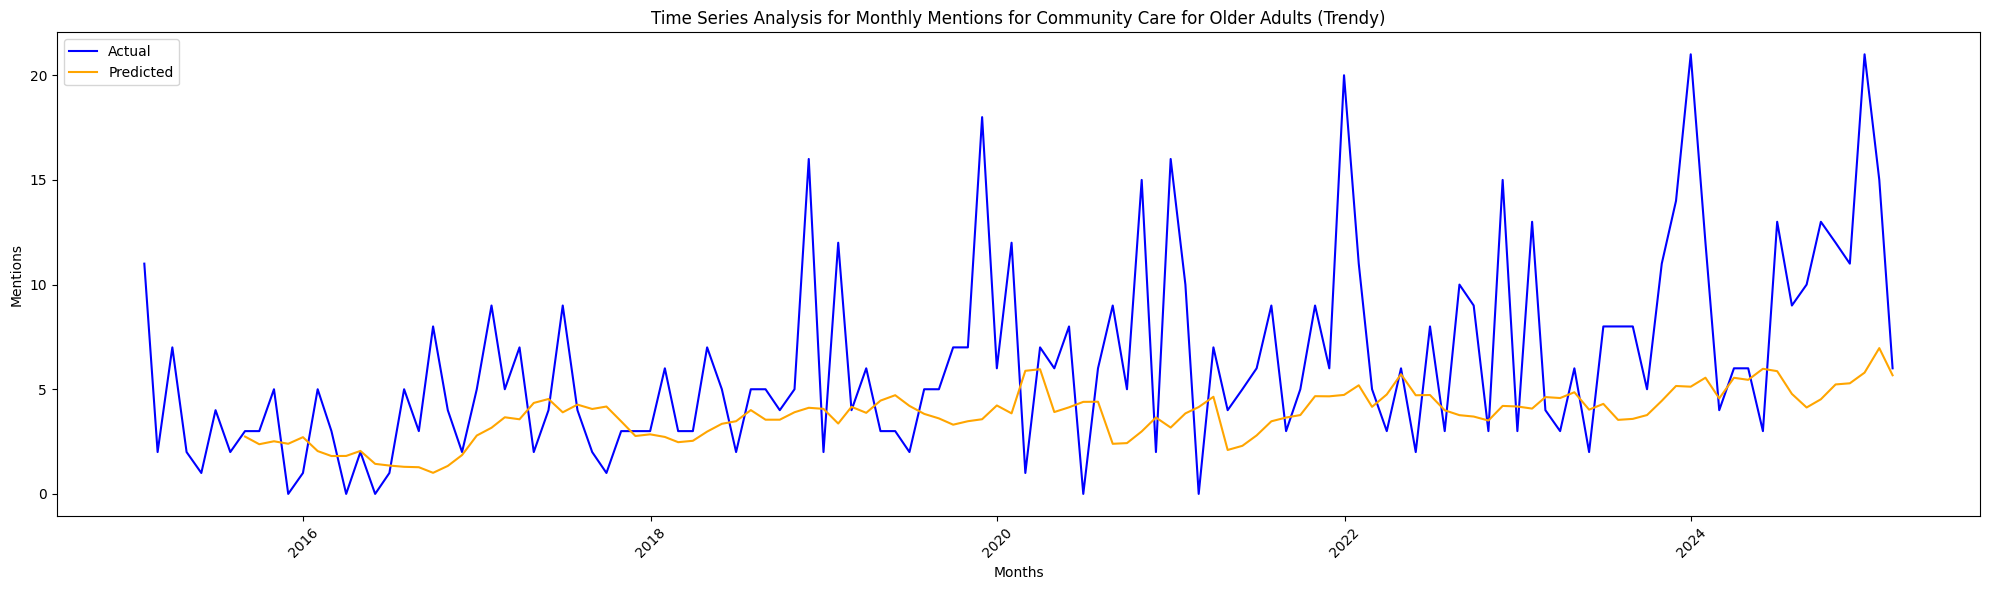

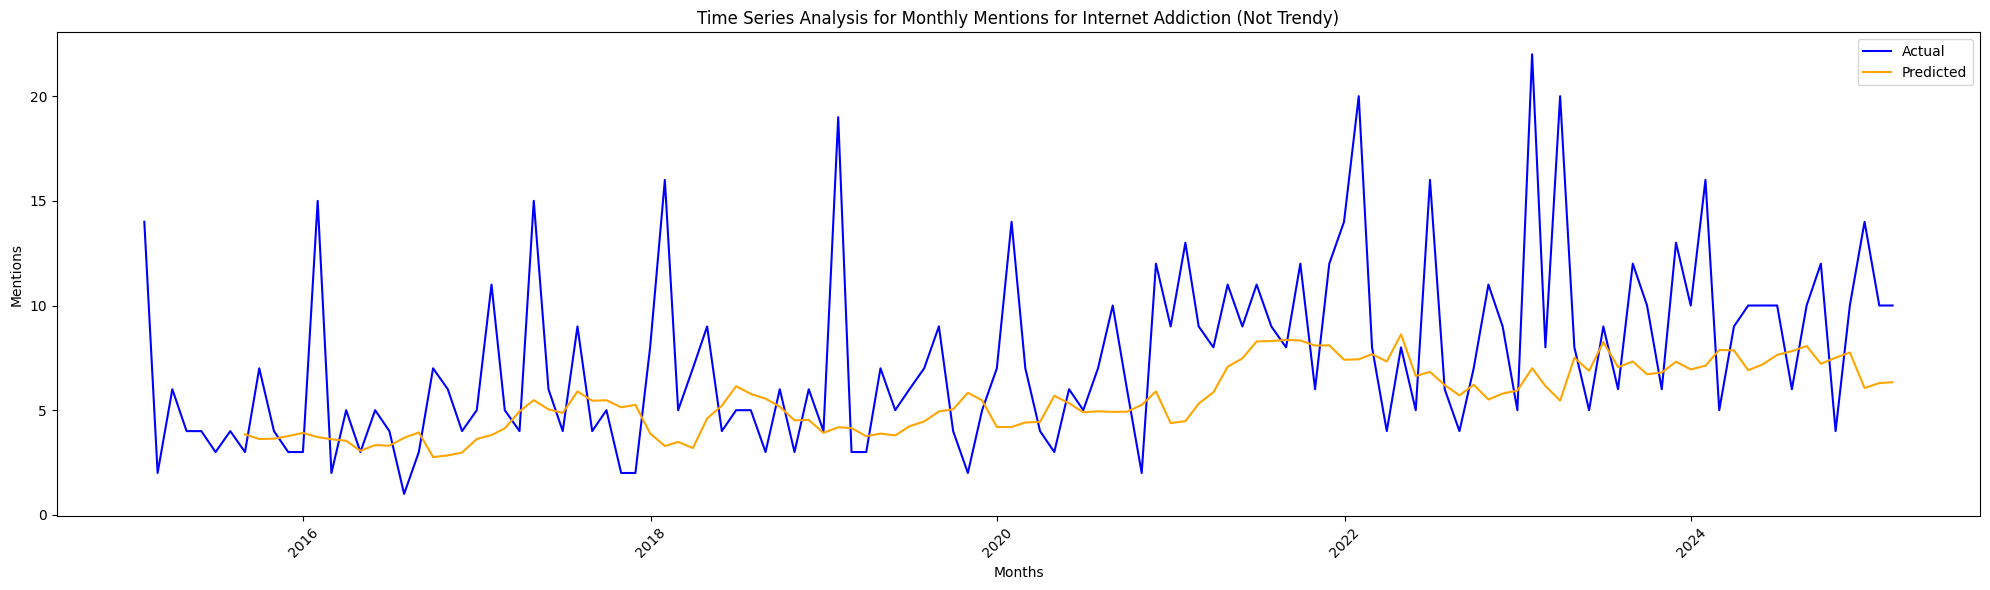

In [13]:
for i in [141,81]:
    plotTopic(i)

In [23]:
def plotMultipleTopics(topicnums): # Six - three trendy, three not trendy
    fig, axes = plt.subplots(3, 2, figsize=(20, 18))
    axes = axes.flatten()  # Convert 2D array to 1D for easier indexing

    for i, topicn in enumerate(topicnums): 
        topicdata = monthly_mentions.loc[:,'Topic'+str(topicn)][:-2]
        topicname = topic_names[topicn]
        predictdata = df_trendy_preds.filter(like='Pred_').iloc[topicn,][:-2]
        trendy = df_trendy_preds['Trendy'].iloc[topicn,]
        trendydesc = "Trendy" if trendy else "Not Trendy"
        ax = axes[i]
        ax.plot(topicdata,label="Actual",color='blue')
        ax.plot(topicdata.index[N_TIMESTEPS+1:], predictdata, label='Predicted', color='orange')
        ax.set_title(f'Time Series Analysis for Monthly Mentions for {topicname} ({trendydesc})')
        ax.set_xlabel('Months')
        ax.set_ylabel('Mentions')
        ax.tick_params(axis='x', rotation=45)
        ax.legend()
    plt.tight_layout()
    plt.savefig('output/figs/trendplots.svg', bbox_inches='tight')
    plt.show()

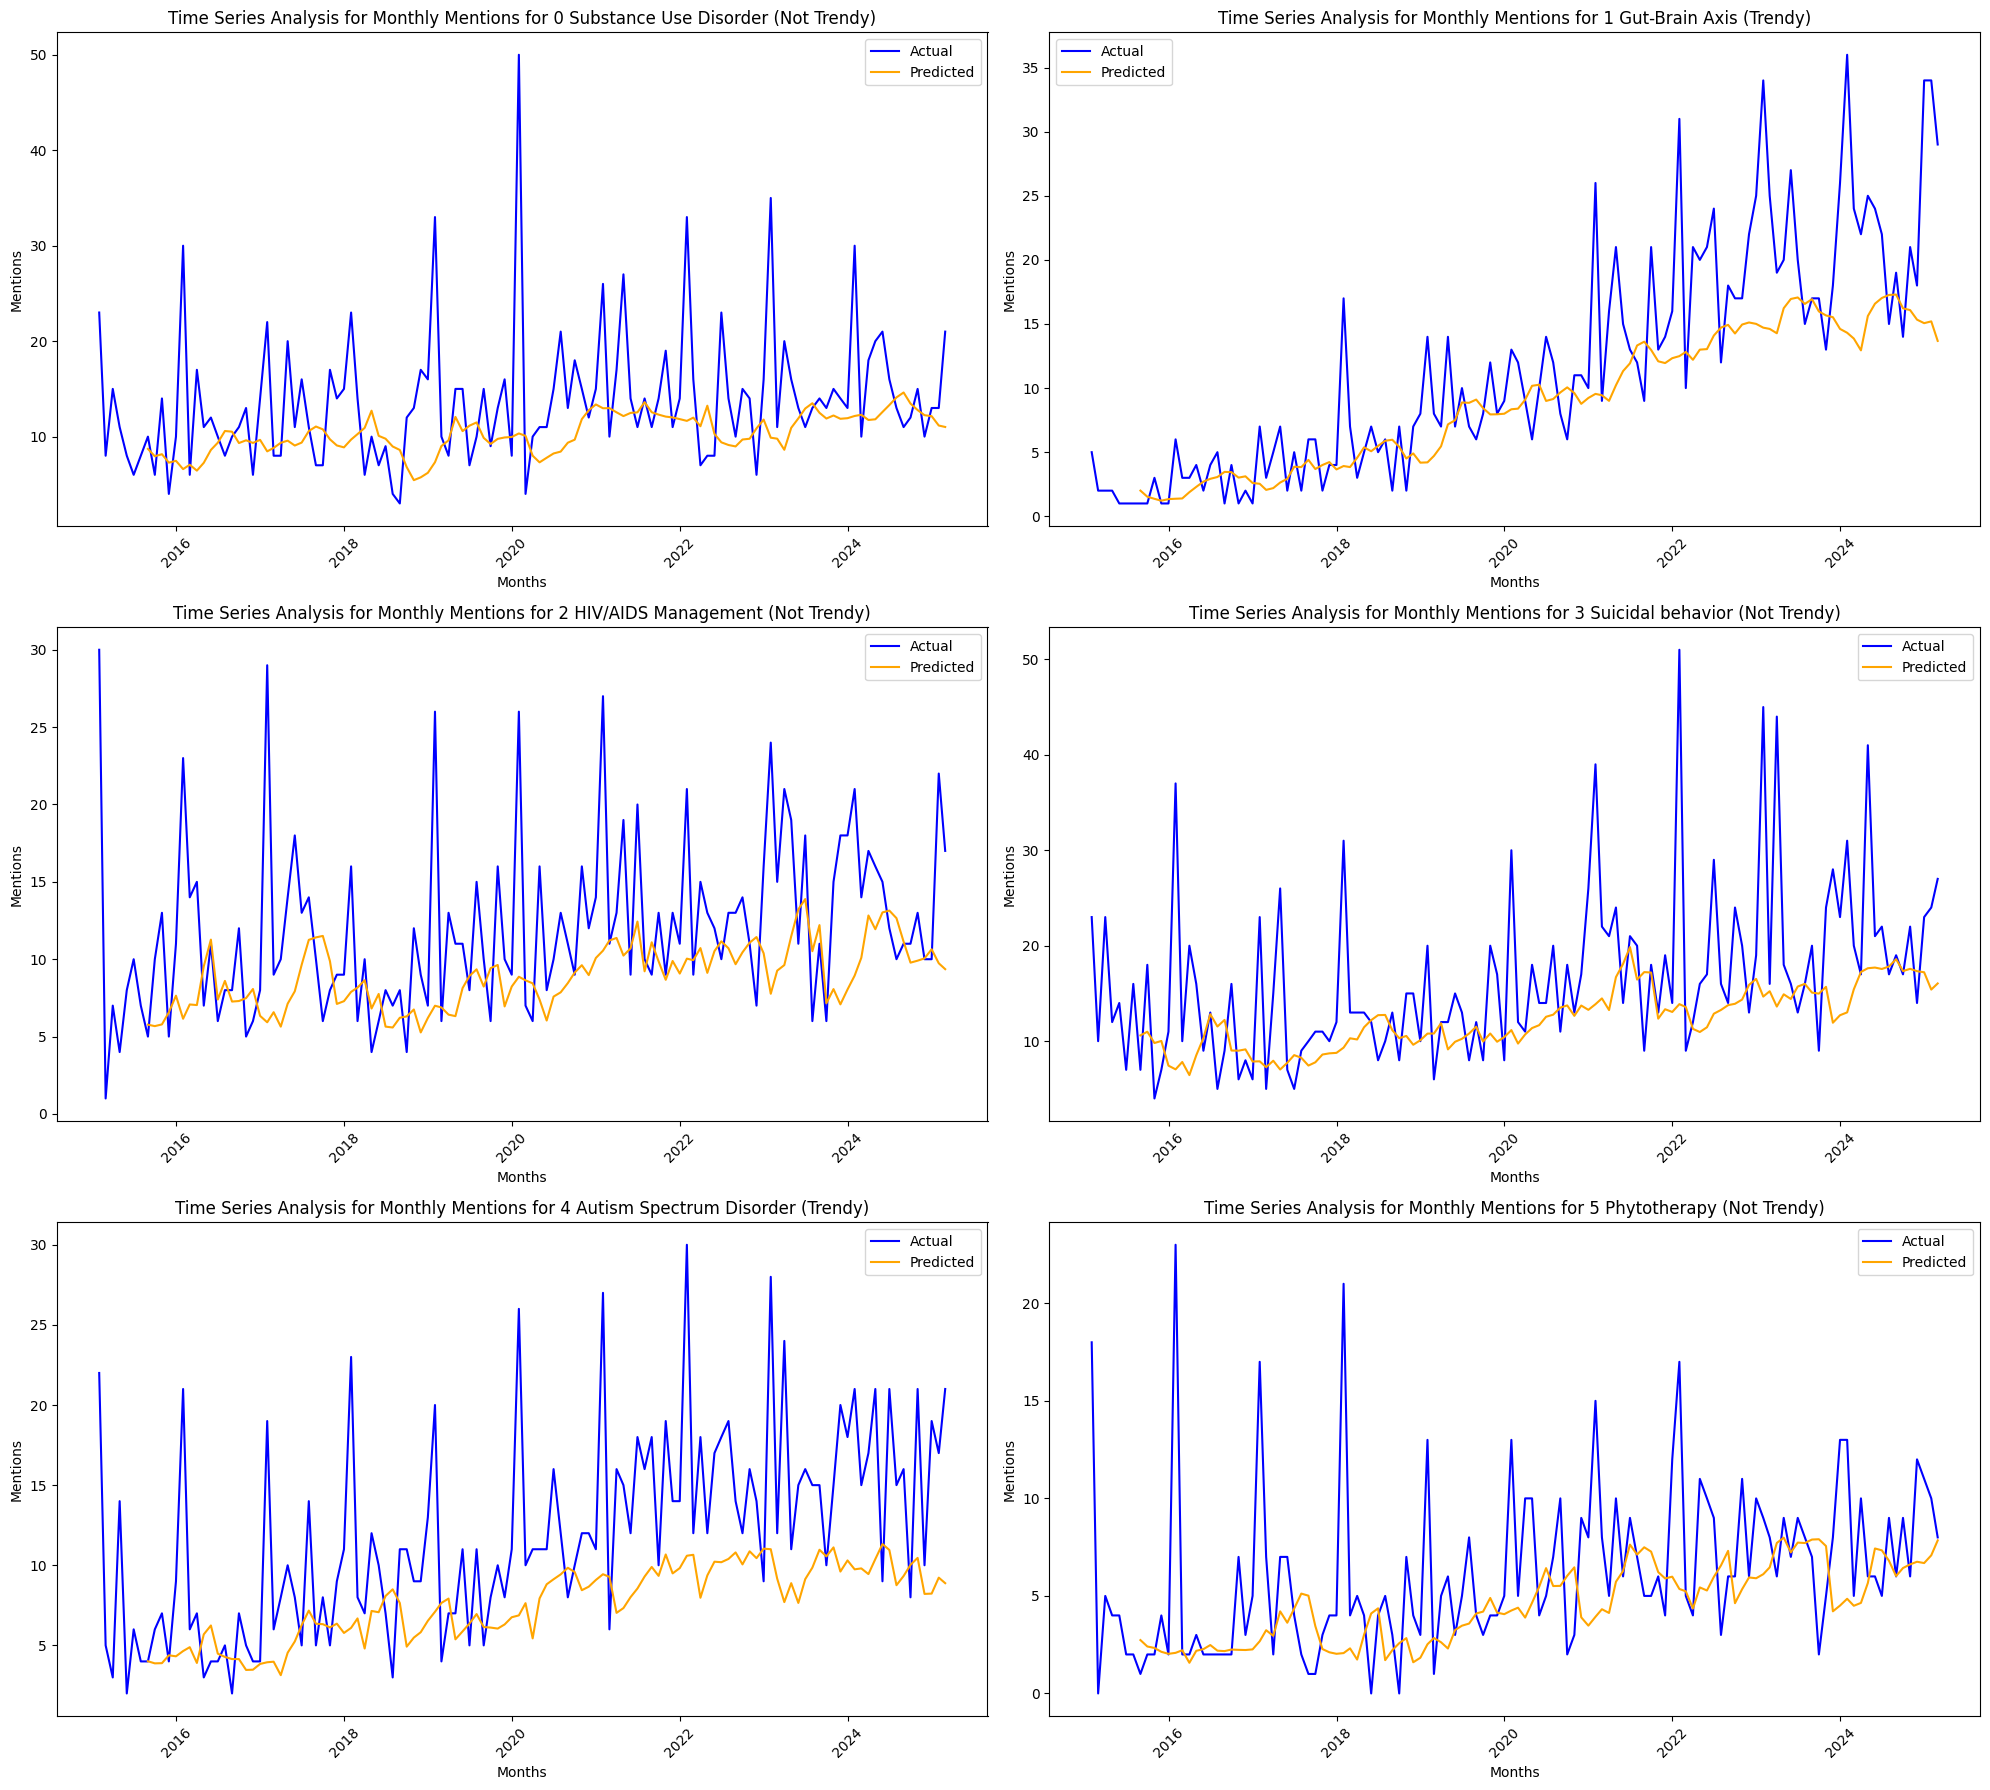

In [19]:
plotMultipleTopics(list(range(6)))

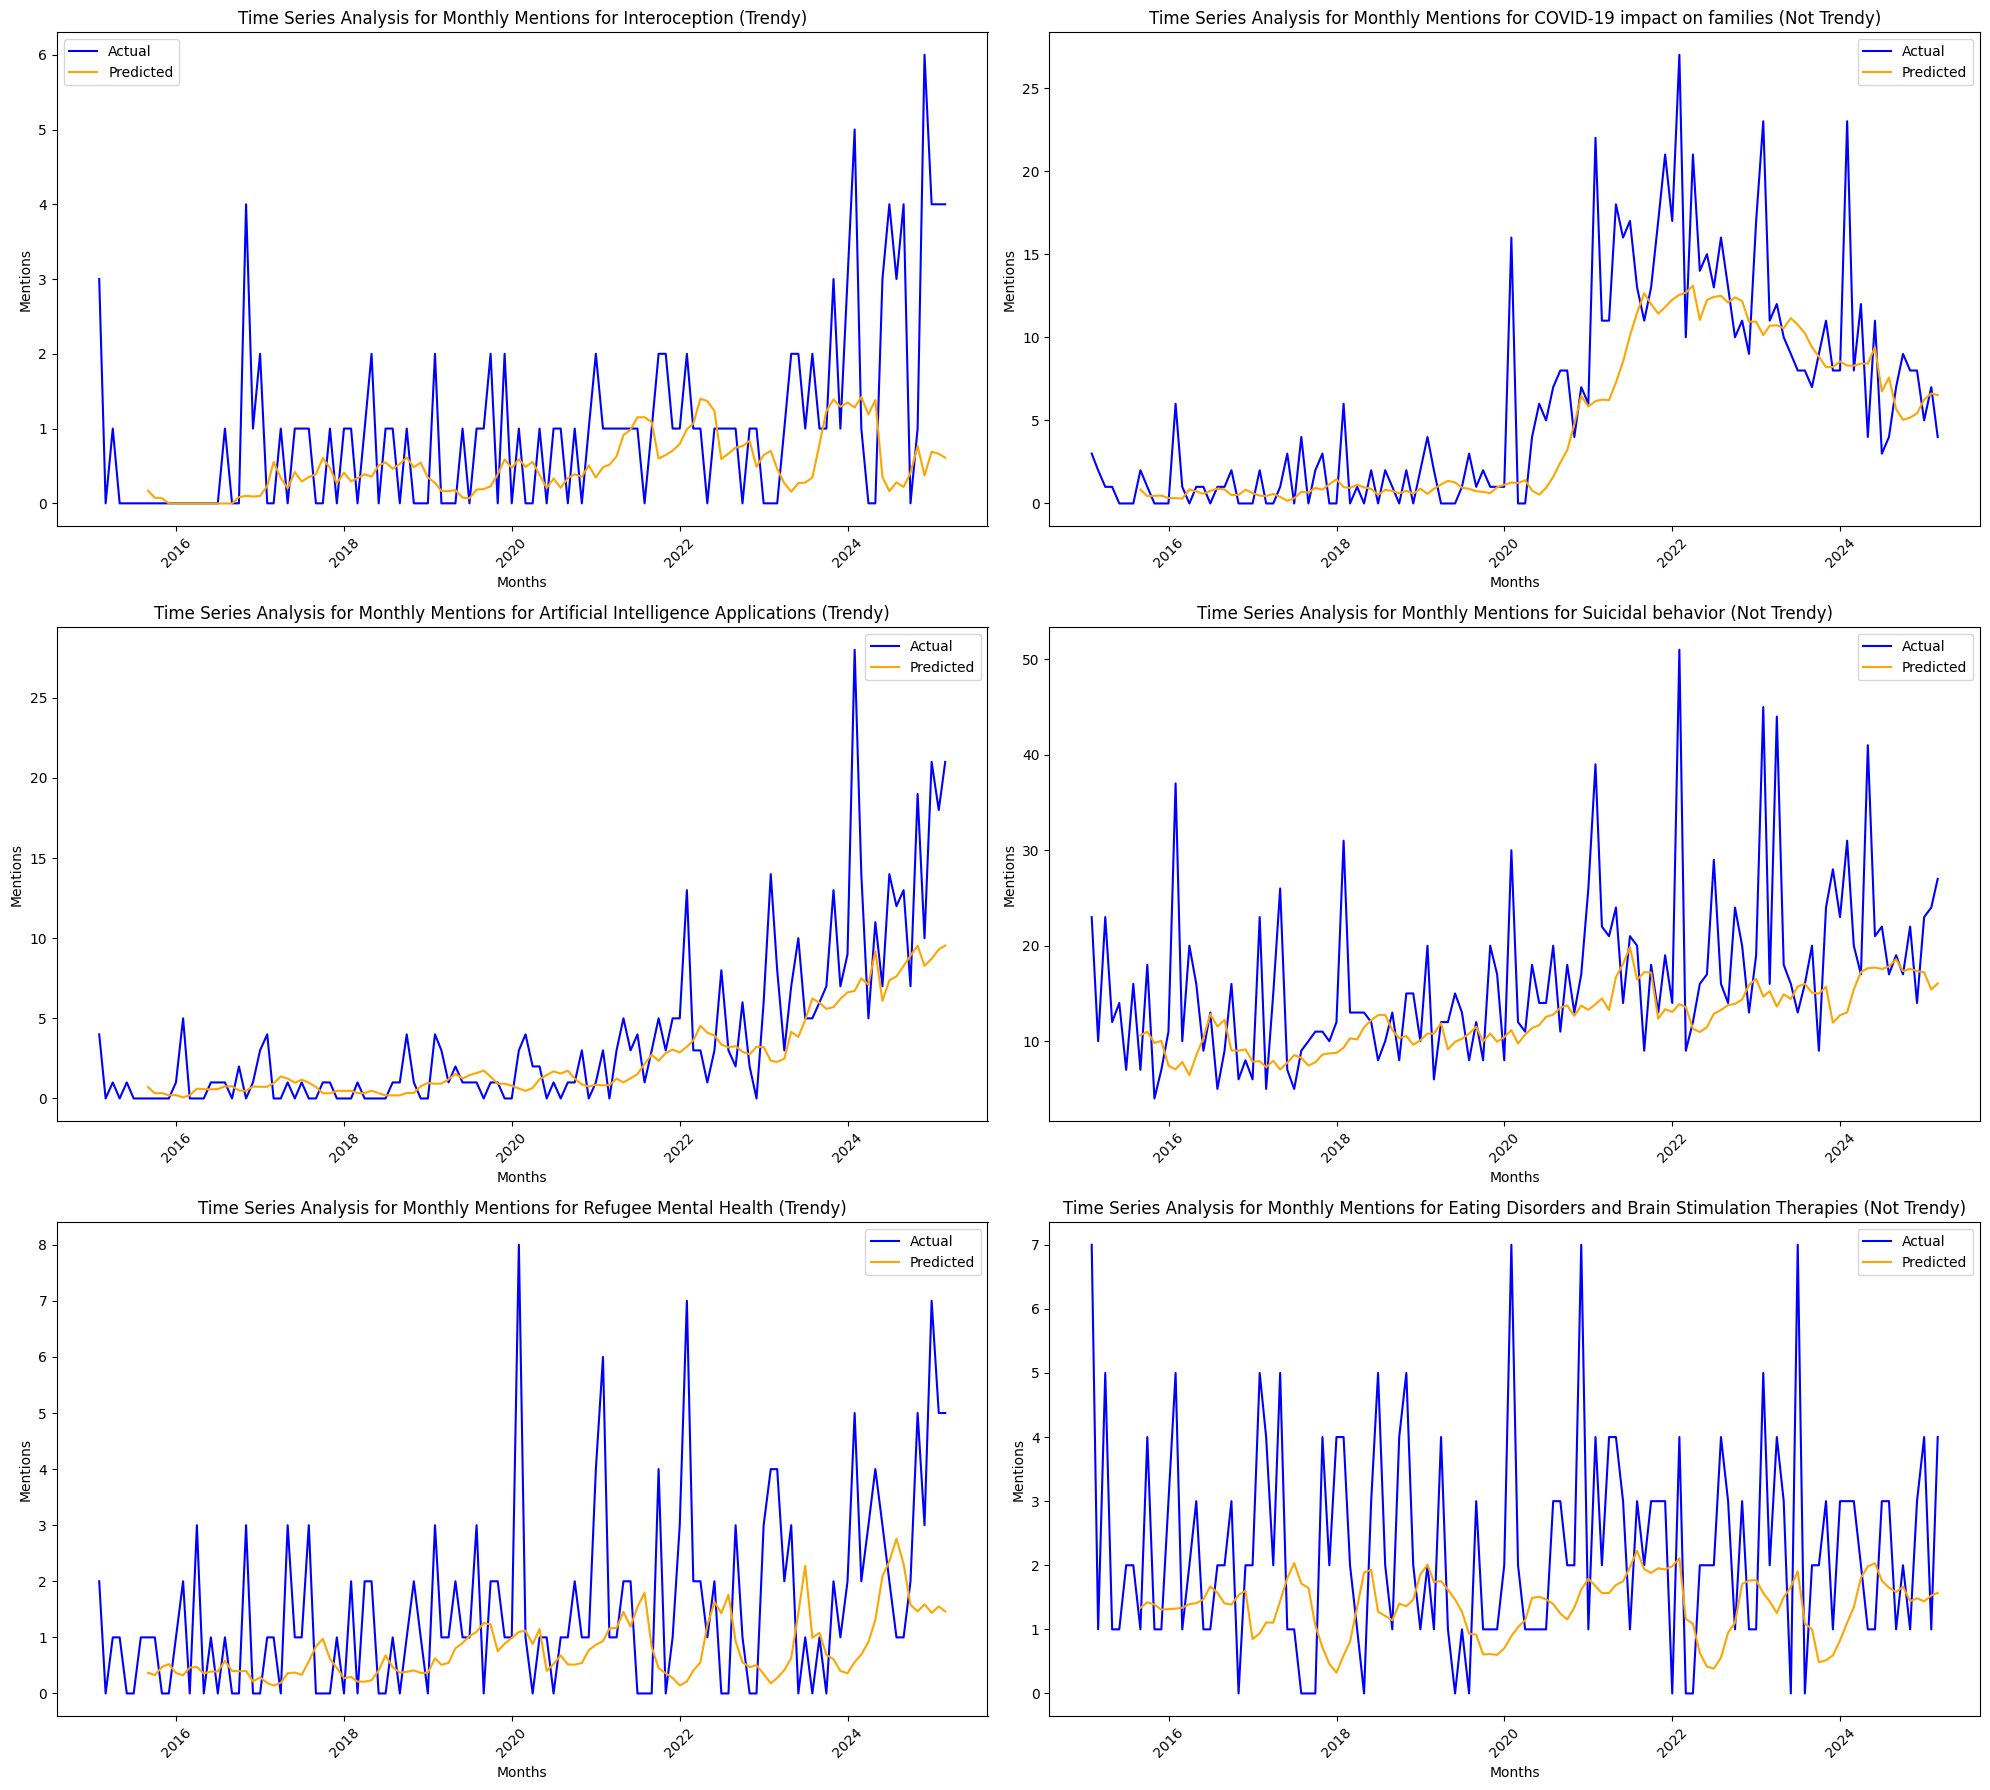

In [24]:
plotMultipleTopics([708,39,336,3,409,606])